In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix
import seaborn as sns
import math
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [2]:
df = pd.read_csv("RT_IOT2022.csv")
df.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


# Missing Values
- No missing values for numerical values and protocol
- Missing values for 'service' but kept

In [4]:
df_cleaned = df.dropna(axis=0)
print(f"{df.shape}, {df_cleaned.shape}")

(123117, 85), (123117, 85)


In [5]:
print(df['Attack_type'].value_counts())

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


In [6]:
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
for i in non_numeric_columns:
    print(i)
    print(df[i].unique())

proto
['tcp' 'udp' 'icmp']
service
['mqtt' '-' 'http' 'dns' 'ntp' 'ssl' 'dhcp' 'irc' 'ssh' 'radius']
Attack_type
['MQTT_Publish' 'Thing_Speak' 'Wipro_bulb' 'ARP_poisioning'
 'DDOS_Slowloris' 'DOS_SYN_Hping' 'Metasploit_Brute_Force_SSH'
 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION' 'NMAP_TCP_scan' 'NMAP_UDP_SCAN'
 'NMAP_XMAS_TREE_SCAN']


In [7]:
print(sum(df['service'] == '-') / len(df))

0.8354735739174931


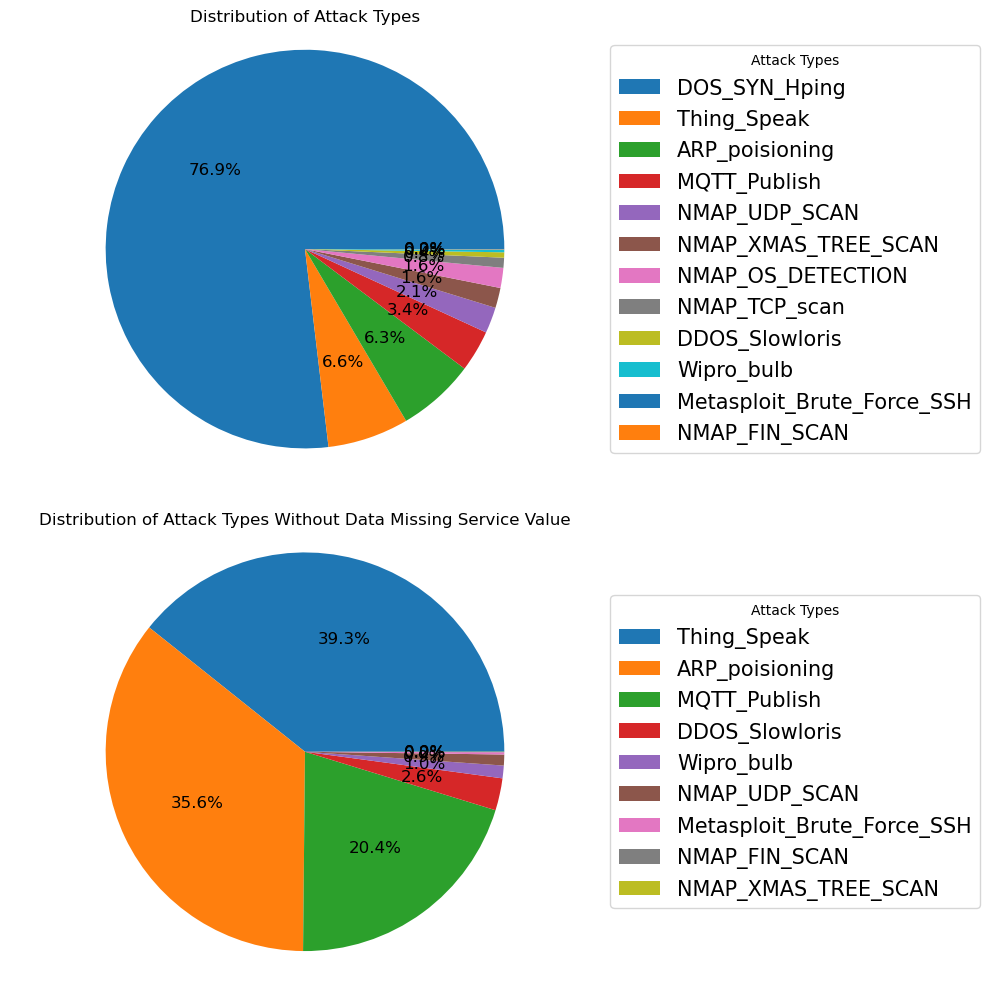

In [8]:
attack_counts1 = df['Attack_type'].value_counts()
attack_counts2 = df.loc[df['service'] != '-', 'Attack_type'].value_counts()

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

wedges1, texts1, autotexts1 = axs[0].pie(
    attack_counts1,
    labels=None,
    autopct='%1.1f%%',
    textprops={'fontsize': 12}
)
axs[0].set_title('Distribution of Attack Types')
axs[0].axis('equal')
axs[0].legend(
    wedges1,
    attack_counts1.index,
    title="Attack Types",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=15
)

wedges2, texts2, autotexts2 = axs[1].pie(
    attack_counts2,
    labels=None,
    autopct='%1.1f%%',
    textprops={'fontsize': 12}
)
axs[1].set_title('Distribution of Attack Types Without Data Missing Service Value')
axs[1].axis('equal')
axs[1].legend(
    wedges2,
    attack_counts2.index,
    title="Attack Types",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=15
)

plt.tight_layout()
plt.show()


In [9]:
ct = pd.crosstab(df['service'], df['Attack_type'])
display(ct)
chi2, p, dof, ex = chi2_contingency(ct)
print(f"Chi2 Statistic: {chi2}, p-value: {p}")

Attack_type,ARP_poisioning,DDOS_Slowloris,DOS_SYN_Hping,MQTT_Publish,Metasploit_Brute_Force_SSH,NMAP_FIN_SCAN,NMAP_OS_DETECTION,NMAP_TCP_scan,NMAP_UDP_SCAN,NMAP_XMAS_TREE_SCAN,Thing_Speak,Wipro_bulb
service,,,,,,,,,,,,
-,546,6,94659,11,0,24,2000,1002,2411,2006,151,45
dhcp,26,2,0,0,0,0,0,0,3,0,14,5
dns,5583,3,0,0,8,3,0,0,31,3,4069,53
http,129,523,0,3,1,1,0,0,139,1,2667,0
irc,0,0,0,0,0,0,0,0,0,0,0,43
mqtt,0,0,0,4132,0,0,0,0,0,0,0,0
ntp,7,0,0,0,0,0,0,0,4,0,110,0
radius,0,0,0,0,0,0,0,0,2,0,0,0
ssh,0,0,0,0,28,0,0,0,0,0,0,0


Chi2 Statistic: 386010.0403133286, p-value: 0.0


# Categorical Features
- Filter out rare categories

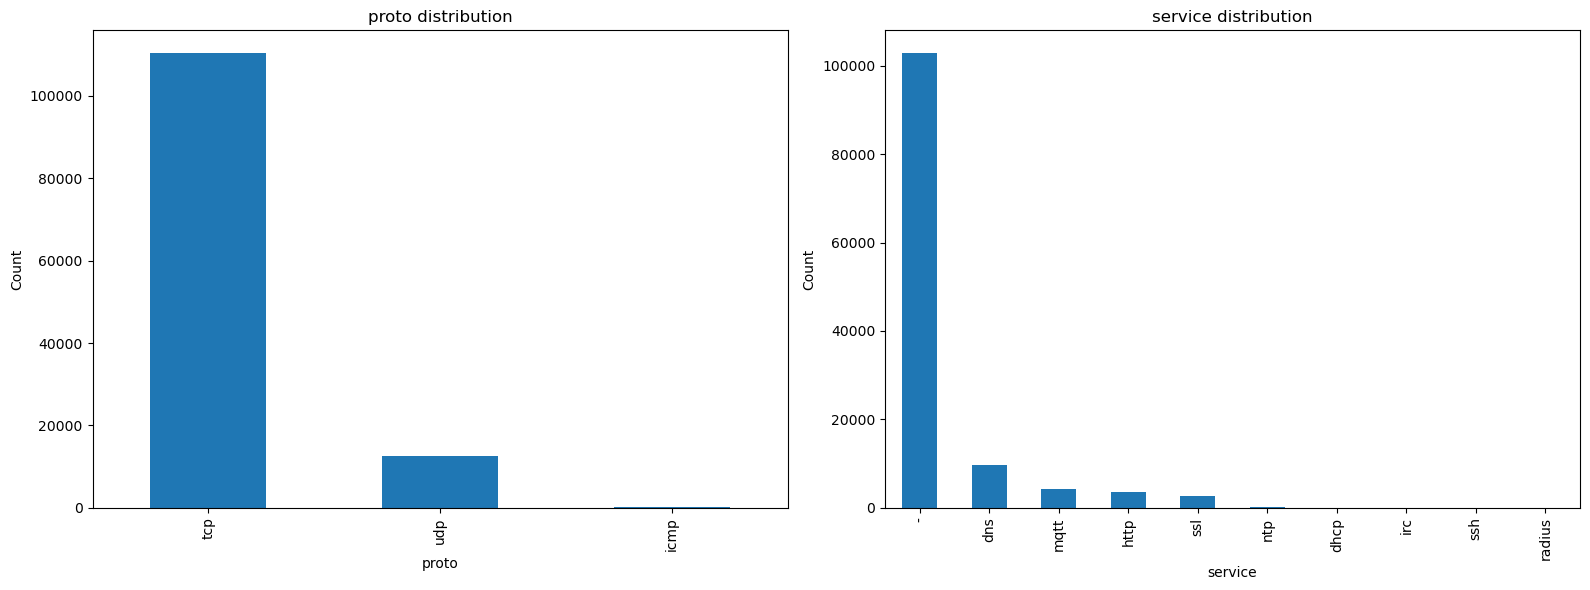

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

for idx, col in enumerate(['proto', 'service']):
    df[col].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f"{col} distribution")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [12]:
print(sum(df['proto'].isin(['tcp', 'udp'])) / len(df))
print(sum(df['service'].isin(['-', 'dns', 'mqtt', 'http', 'ssl'])) / len(df))

0.9995370257559882
0.9980181453414232


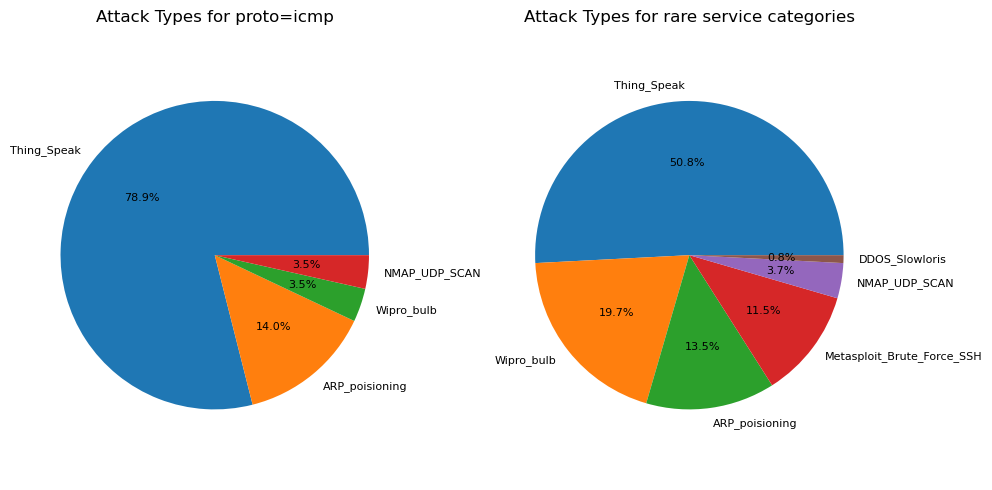

In [13]:
attack_counts_icmp = df.loc[df['proto'] == 'icmp', 'Attack_type'].value_counts()
attack_counts_service = df.loc[df['service'].isin(['ntp', 'dhcp', 'irc', 'ssh', 'radius']), 'Attack_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  

axes[0].pie(
    attack_counts_icmp,
    labels=attack_counts_icmp.index,
    autopct='%1.1f%%',
    textprops={'fontsize': 8}
)
axes[0].set_title('Attack Types for proto=icmp')
axes[0].axis('equal')  

axes[1].pie(
    attack_counts_service,
    labels=attack_counts_service.index,
    autopct='%1.1f%%',
    textprops={'fontsize': 8}
)
axes[1].set_title('Attack Types for rare service categories')
axes[1].axis('equal')

plt.tight_layout()
plt.show()


In [14]:
df = df.loc[(df['proto'] != 'icmp') & (df['service'].isin(['-', 'dns', 'mqtt', 'http', 'ssl']))]
df.shape

(122816, 85)

# Delete ID and Port Number Columns
- ID
- id.orig_p & id.resp_p: should be treated as categorical data but too diverse

In [16]:
df = df.iloc[:,1:]
df.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [17]:
print(len(df['id.orig_p'].unique()))
print(len(df['id.resp_p'].unique()))

65478
1805


In [18]:
df = df.drop(columns=['id.orig_p', 'id.resp_p'])
df.head()

,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


# Feature Construction

In [20]:
df['flag_SYN_ACK_ratio'] = df['flow_SYN_flag_count'] / (df['flow_ACK_flag_count'] + 1)
df['flag_RST_ratio'] = df['flow_RST_flag_count'] / (df['flow_FIN_flag_count'] + 1)

# One-Hot Encoding

In [22]:
cat_features = df[['proto', 'service']]
encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = encoder.fit_transform(cat_features)

encoded_feature_names = encoder.get_feature_names_out(['proto', 'service'])
df_cat_encoded = pd.DataFrame(cat_encoded, columns=encoded_feature_names, index=df.index)


df_numeric = df.drop(columns=['proto', 'service', 'Attack_type'])  
X = pd.concat([df_numeric, df_cat_encoded], axis=1)

In [23]:
cat = df['Attack_type'].astype('category')
mapping = dict(enumerate(cat.cat.categories))
print(mapping)
y = df['Attack_type'].astype('category').cat.codes

{0: 'ARP_poisioning', 1: 'DDOS_Slowloris', 2: 'DOS_SYN_Hping', 3: 'MQTT_Publish', 4: 'Metasploit_Brute_Force_SSH', 5: 'NMAP_FIN_SCAN', 6: 'NMAP_OS_DETECTION', 7: 'NMAP_TCP_scan', 8: 'NMAP_UDP_SCAN', 9: 'NMAP_XMAS_TREE_SCAN', 10: 'Thing_Speak', 11: 'Wipro_bulb'}


# Delete High-Correlation Features
- Grouping and selecting the column with the highest MI in each group

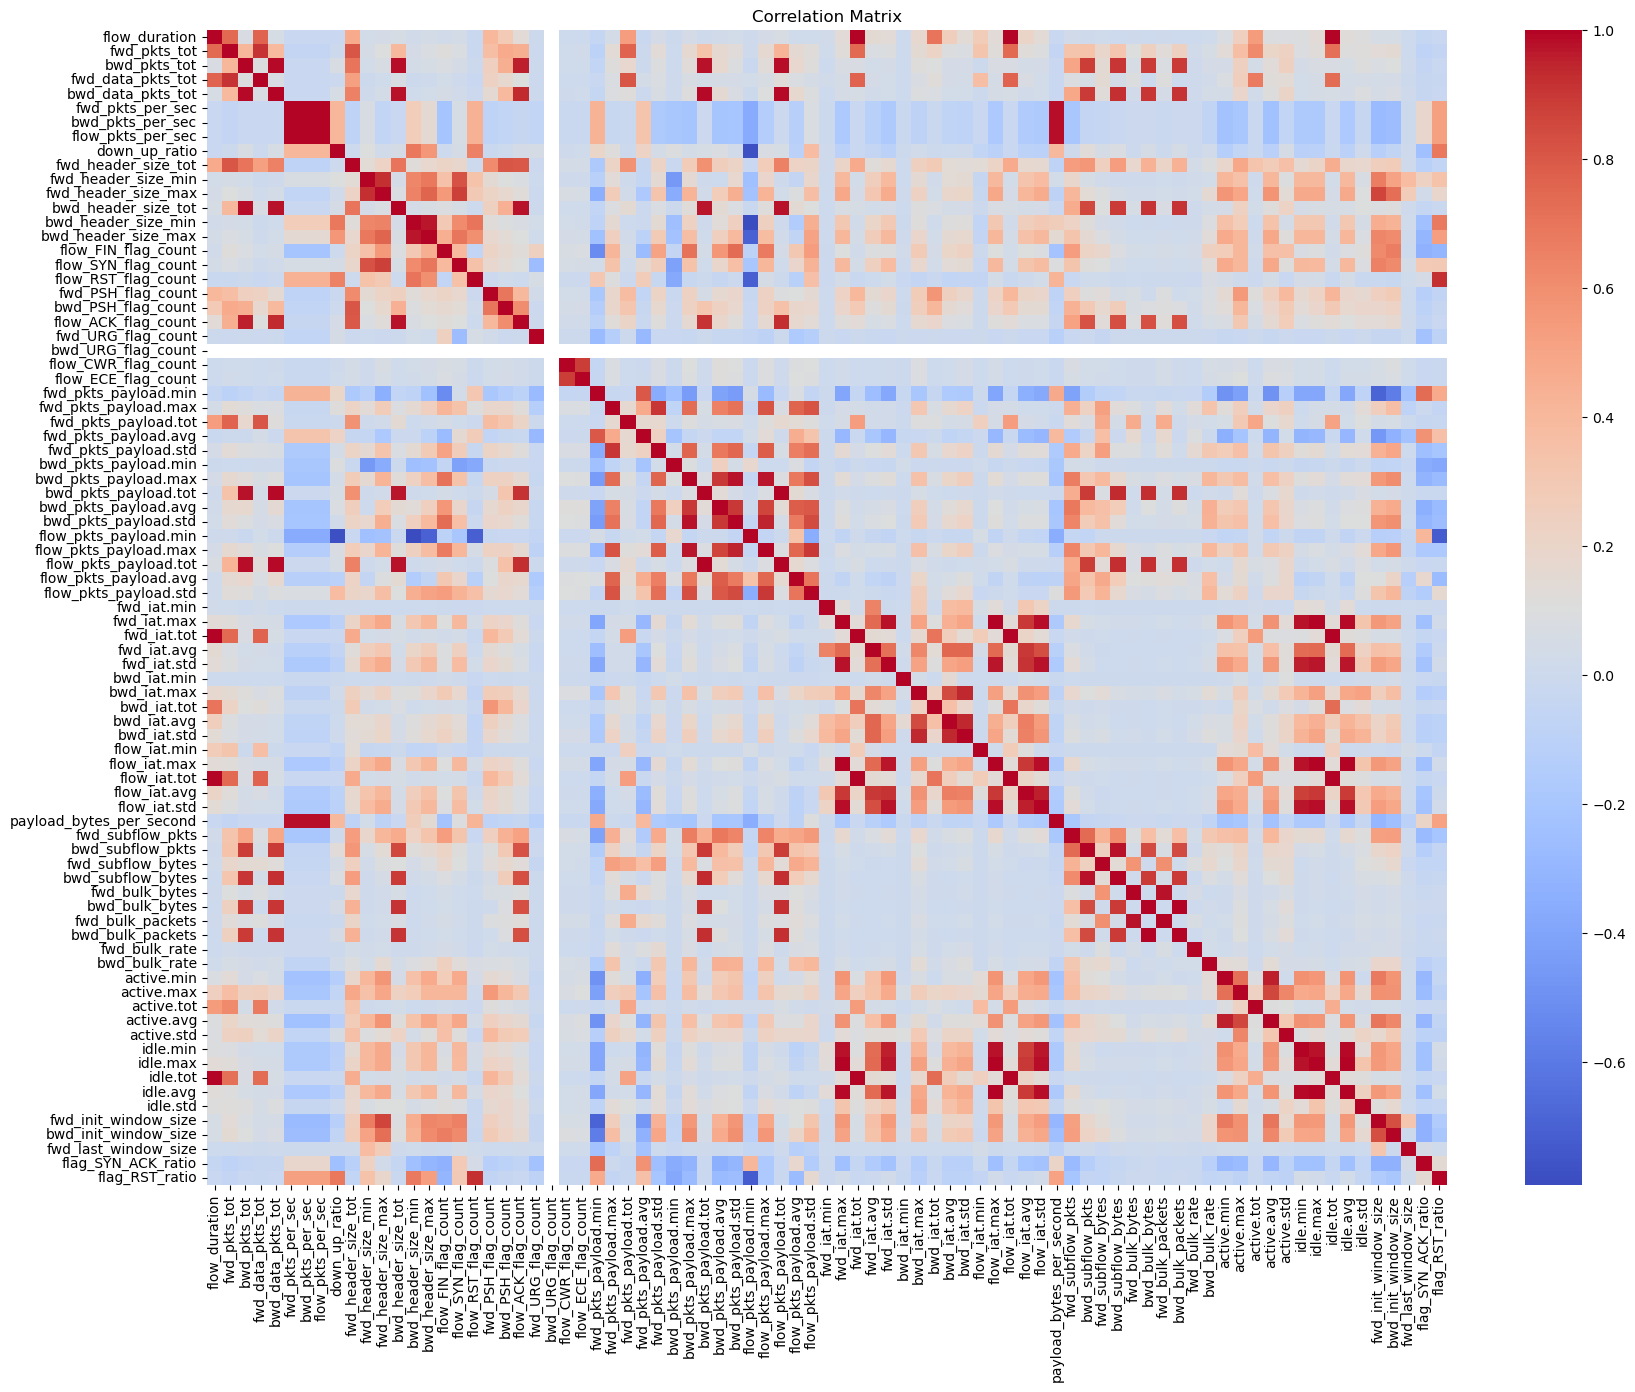

In [25]:
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [26]:
correlation_matrix_abs = correlation_matrix.abs()
np.fill_diagonal(correlation_matrix_abs.values, 0)

high_corr_pairs = (
    correlation_matrix_abs.where(np.triu(np.ones(correlation_matrix_abs.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.9]

groups = []
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row['Feature 1'], row['Feature 2']
    added = False
    for group in groups:
        if f1 in group or f2 in group:
            group.update([f1, f2])
            added = True
            break
    if not added:
        groups.append(set([f1, f2]))

merged = []
for group in groups:
    found = False
    for m in merged:
        if group & m:
            m.update(group)
            found = True
            break
    if not found:
        merged.append(set(group))

In [27]:
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_df = pd.Series(mi_scores, index=X.columns)

selected_features = []

for i, group in enumerate(merged, 1):
    group_list = list(group)
    group_mi = mi_df[group_list].sort_values(ascending=False)
    top_feature = group_mi.idxmax()
    selected_features.append(top_feature)
    print(f"Group {i}: {group_list}, Selected: {top_feature}")

Group 1: ['fwd_iat.tot', 'flow_duration', 'flow_iat.tot', 'idle.tot'], Selected: flow_duration
Group 2: ['fwd_data_pkts_tot', 'fwd_pkts_tot'], Selected: fwd_data_pkts_tot
Group 3: ['flow_ACK_flag_count', 'bwd_subflow_pkts', 'bwd_data_pkts_tot', 'bwd_header_size_tot', 'bwd_bulk_packets', 'bwd_subflow_bytes', 'flow_pkts_payload.tot', 'bwd_bulk_bytes', 'bwd_pkts_tot', 'bwd_pkts_payload.tot'], Selected: flow_pkts_payload.tot
Group 4: ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'payload_bytes_per_second', 'flow_pkts_per_sec'], Selected: fwd_pkts_per_sec
Group 5: ['fwd_header_size_min', 'fwd_header_size_max'], Selected: fwd_header_size_max
Group 6: ['bwd_header_size_max', 'bwd_header_size_min'], Selected: bwd_header_size_max
Group 7: ['flag_RST_ratio', 'flow_RST_flag_count'], Selected: flag_RST_ratio
Group 8: ['fwd_pkts_payload.std', 'fwd_pkts_payload.max'], Selected: fwd_pkts_payload.max
Group 9: ['flow_pkts_payload.max', 'bwd_pkts_payload.std', 'bwd_pkts_payload.max', 'bwd_pkts_payload.avg'],

In [28]:
all_features = set(mi_df.index)
grouped_features = set().union(*merged)
ungrouped_features = all_features - grouped_features
not_high_corr_features = set(selected_features) | ungrouped_features

In [29]:
X = X[list(not_high_corr_features)]

In [30]:
X.head()

,service_ssl,active.std,bwd_init_window_size,fwd_PSH_flag_count,flow_FIN_flag_count,bwd_iat.max,down_up_ratio,proto_udp,flow_pkts_payload.max,flow_pkts_payload.tot,...,service_mqtt,fwd_pkts_payload.tot,fwd_init_window_size,flow_iat.max,flow_CWR_flag_count,flow_pkts_payload.min,fwd_bulk_bytes,fwd_URG_flag_count,flow_SYN_flag_count,flow_iat.min
0,0.0,0.0,26847,3,0,1.511694e+06,0.555556,0.0,33.0,108.0,...,1.0,76.0,64240,2.972918e+07,0,0.0,0.0,0,2,761.985779
1,0.0,0.0,26847,3,0,1.576436e+06,0.555556,0.0,33.0,108.0,...,1.0,76.0,64240,2.985528e+07,0,0.0,0.0,0,2,247.001648
2,0.0,0.0,26847,3,0,1.476049e+06,0.555556,0.0,33.0,104.0,...,1.0,74.0,64240,2.984215e+07,0,0.0,0.0,0,2,283.956528
3,0.0,0.0,26847,3,0,1.551892e+06,0.555556,0.0,33.0,104.0,...,1.0,74.0,64240,2.991377e+07,0,0.0,0.0,0,2,288.963318
4,0.0,0.0,26847,3,0,1.632083e+06,0.555556,0.0,33.0,108.0,...,1.0,76.0,64240,2.981470e+07,0,0.0,0.0,0,2,387.907028


# Delete Features with MI < 0.1

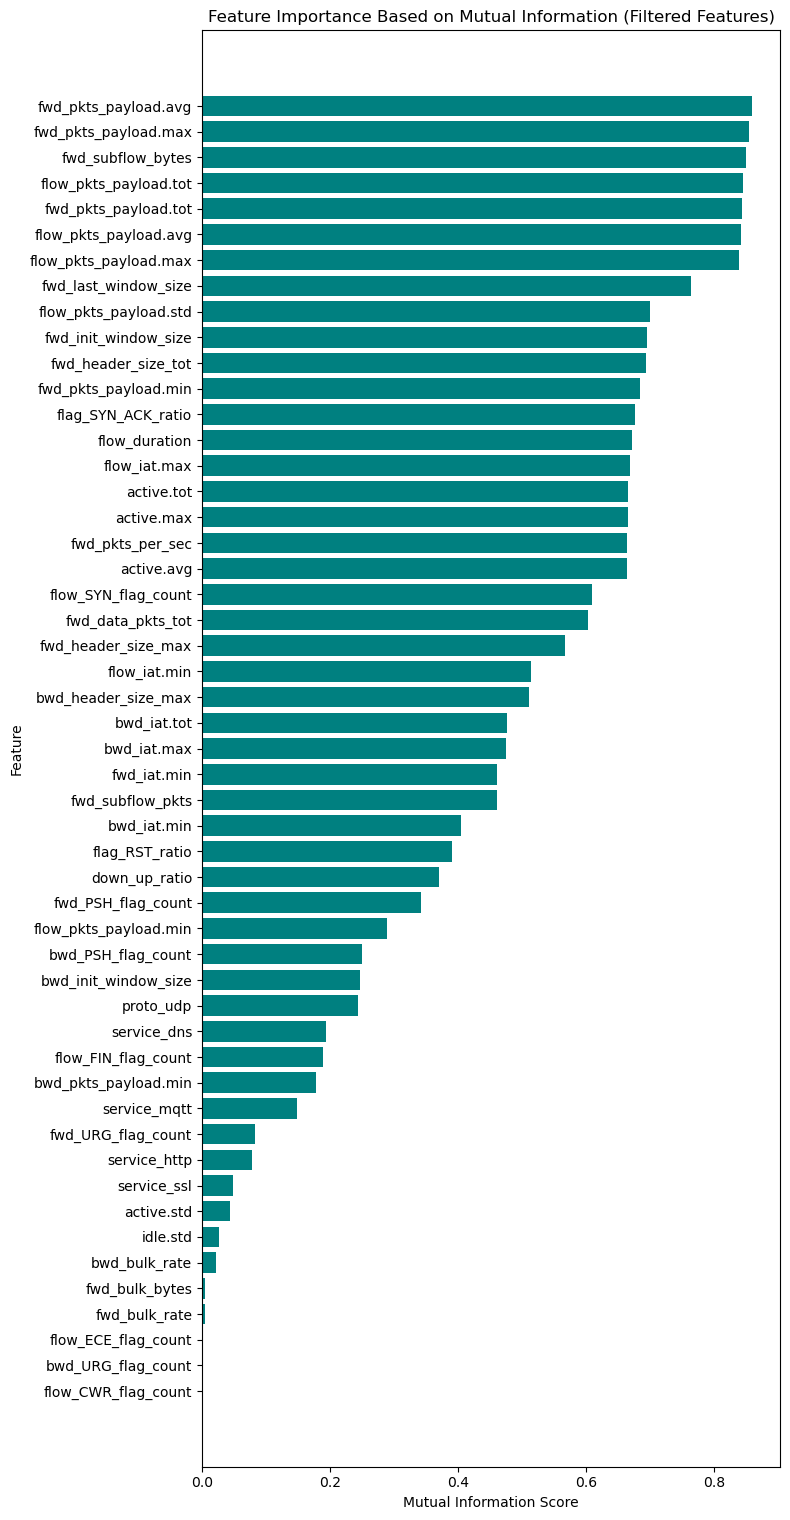

In [32]:
filtered_mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
filtered_mi_df = pd.Series(filtered_mi_scores, index=X.columns).sort_values()

plt.figure(figsize=(8, max(6, 0.3 * len(filtered_mi_df)))) 
plt.barh(filtered_mi_df.index, filtered_mi_df.values, color='teal')
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information (Filtered Features)")
plt.tight_layout()
plt.show()


In [33]:
X = X[filtered_mi_df.index[filtered_mi_df.values >= 0.1]]
X.head()

,service_mqtt,bwd_pkts_payload.min,flow_FIN_flag_count,service_dns,proto_udp,bwd_init_window_size,bwd_PSH_flag_count,flow_pkts_payload.min,fwd_PSH_flag_count,down_up_ratio,...,fwd_init_window_size,flow_pkts_payload.std,fwd_last_window_size,flow_pkts_payload.max,flow_pkts_payload.avg,fwd_pkts_payload.tot,flow_pkts_payload.tot,fwd_subflow_bytes,fwd_pkts_payload.max,fwd_pkts_payload.avg
0,1.0,0.0,0,0.0,0.0,26847,3,0.0,3,0.555556,...,64240,11.618477,502,33.0,7.714286,76.0,108.0,25.333333,33.0,8.444444
1,1.0,0.0,0,0.0,0.0,26847,3,0.0,3,0.555556,...,64240,11.618477,502,33.0,7.714286,76.0,108.0,25.333333,33.0,8.444444
2,1.0,0.0,0,0.0,0.0,26847,3,0.0,3,0.555556,...,64240,11.229866,502,33.0,7.428571,74.0,104.0,24.666667,33.0,8.222222
3,1.0,0.0,0,0.0,0.0,26847,3,0.0,3,0.555556,...,64240,11.229866,502,33.0,7.428571,74.0,104.0,24.666667,33.0,8.222222
4,1.0,0.0,0,0.0,0.0,26847,3,0.0,3,0.555556,...,64240,11.618477,502,33.0,7.714286,76.0,108.0,25.333333,33.0,8.444444


# Numeric Features Standardisation

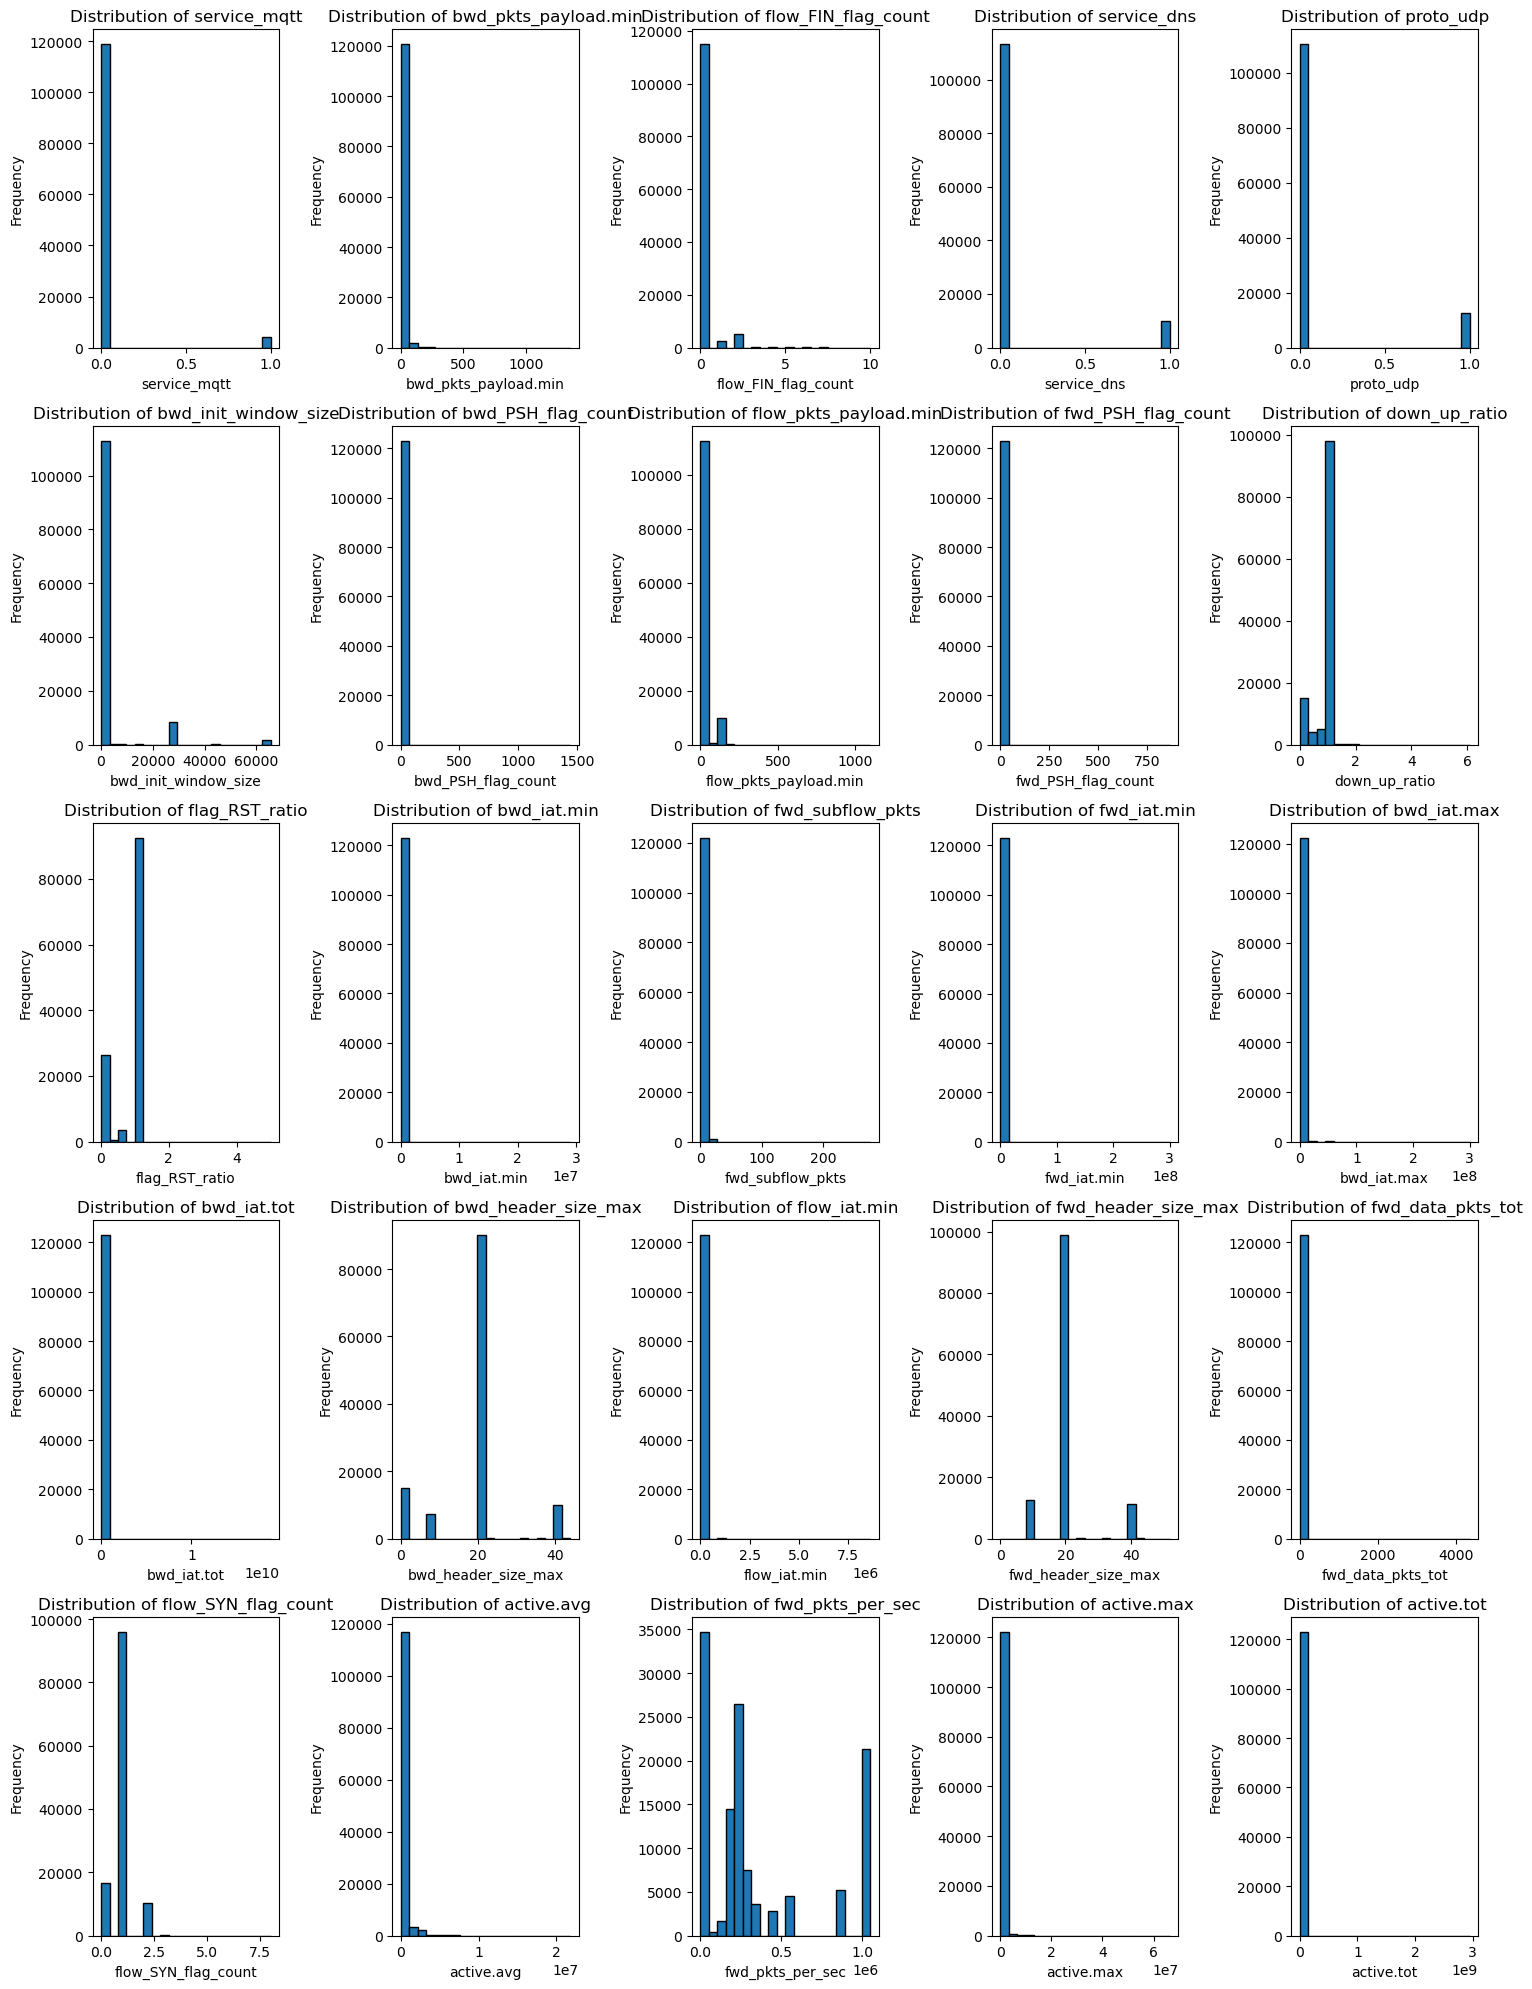

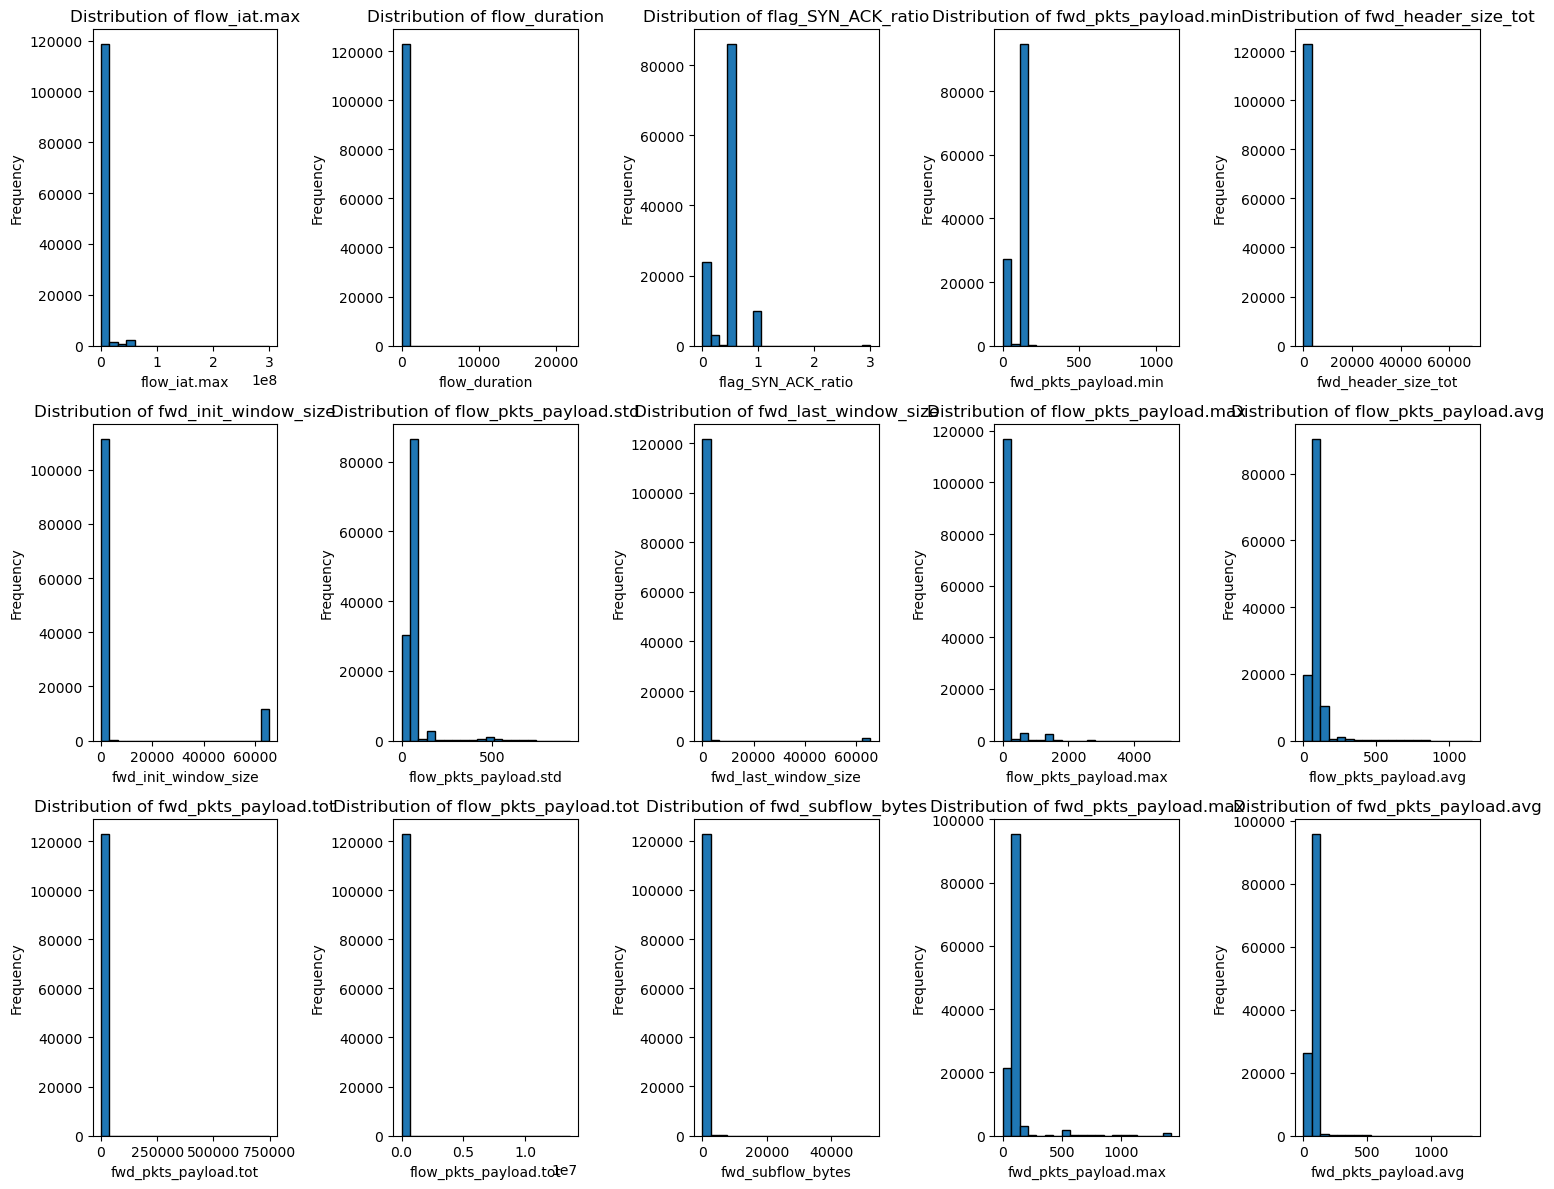

In [35]:
selected_numeric_features = X.select_dtypes(include=['number']).columns
plots_per_page = 25
num_plots = len(selected_numeric_features)

for start in range(0, num_plots, plots_per_page):
    end = min(start + plots_per_page, num_plots)
    cols = 5
    rows = (end - start + cols - 1) // cols 

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()  

    for i, col_name in enumerate(selected_numeric_features[start:end]):
        data = X[col_name].dropna()
        axes[i].hist(data, bins=20, edgecolor='black')
        axes[i].set_title(f'Distribution of {col_name}')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [36]:
exclude_log_cols = [
    'flow_FIN_flag_count', 'down_up_ratio', 'flag_RST_ratio', 'bwd_header_size_max', 
    'fwd_header_size_max', 'flow_SYN_flag_count', 'fwd_pkts_per_sec', 'flag_SYN_ACK_ratio'
]

log_cols = [col for col in selected_numeric_features if col not in exclude_log_cols]

epsilon = 1e-6
X_scaled = X[selected_numeric_features].copy()
for col in log_cols:
    X_scaled[col] = np.log(X[col] + epsilon)

scaler = StandardScaler()
X_scaled[selected_numeric_features] = scaler.fit_transform(X_scaled[selected_numeric_features])

In [37]:
X_scaled.describe()

,service_mqtt,bwd_pkts_payload.min,flow_FIN_flag_count,service_dns,proto_udp,bwd_init_window_size,bwd_PSH_flag_count,flow_pkts_payload.min,fwd_PSH_flag_count,down_up_ratio,...,fwd_init_window_size,flow_pkts_payload.std,fwd_last_window_size,flow_pkts_payload.max,flow_pkts_payload.avg,fwd_pkts_payload.tot,flow_pkts_payload.tot,fwd_subflow_bytes,fwd_pkts_payload.max,fwd_pkts_payload.avg
count,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,...,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05
mean,-2.166063e-16,9.256680e-17,-8.516145e-17,3.961859e-16,-3.258351e-16,-4.184019e-16,2.369710e-16,-1.670831e-16,6.294542e-17,1.407015e-16,...,-2.369710e-16,2.962138e-17,-2.999164e-16,-3.850779e-16,2.073496e-16,-3.850779e-16,-5.331848e-16,-4.739420e-16,-6.516703e-16,-5.924275e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,-2.537720e+00,...,-2.800696e+00,-2.257633e+00,-2.737414e+00,-4.108683e+00,-4.110417e+00,-4.113568e+00,-4.079001e+00,-4.113100e+00,-4.114502e+00,-4.098390e+00
25%,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,4.294865e-01,...,1.795638e-01,3.879106e-01,2.970300e-01,2.379029e-01,2.385538e-01,2.370450e-01,1.994091e-01,2.512891e-01,2.606354e-01,2.965159e-01
50%,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,4.294865e-01,...,1.795638e-01,4.563212e-01,2.970300e-01,2.379029e-01,2.385538e-01,2.370450e-01,1.994091e-01,2.512891e-01,2.606354e-01,2.965159e-01
75%,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,4.294865e-01,...,1.795638e-01,4.563212e-01,2.970300e-01,2.379029e-01,2.385538e-01,2.370450e-01,1.994091e-01,2.512891e-01,2.606354e-01,2.965159e-01
max,5.359397e+00,4.717111e+00,2.088252e+01,3.404796e+00,2.976041e+00,3.426737e+00,4.889997e+00,2.634373e+00,4.289712e+00,1.552633e+01,...,1.328840e+00,8.113894e-01,1.467201e+00,1.115070e+00,9.569410e-01,2.280283e+00,2.876173e+00,1.676011e+00,8.417575e-01,8.628982e-01


In [38]:
X = X_scaled

# PCA

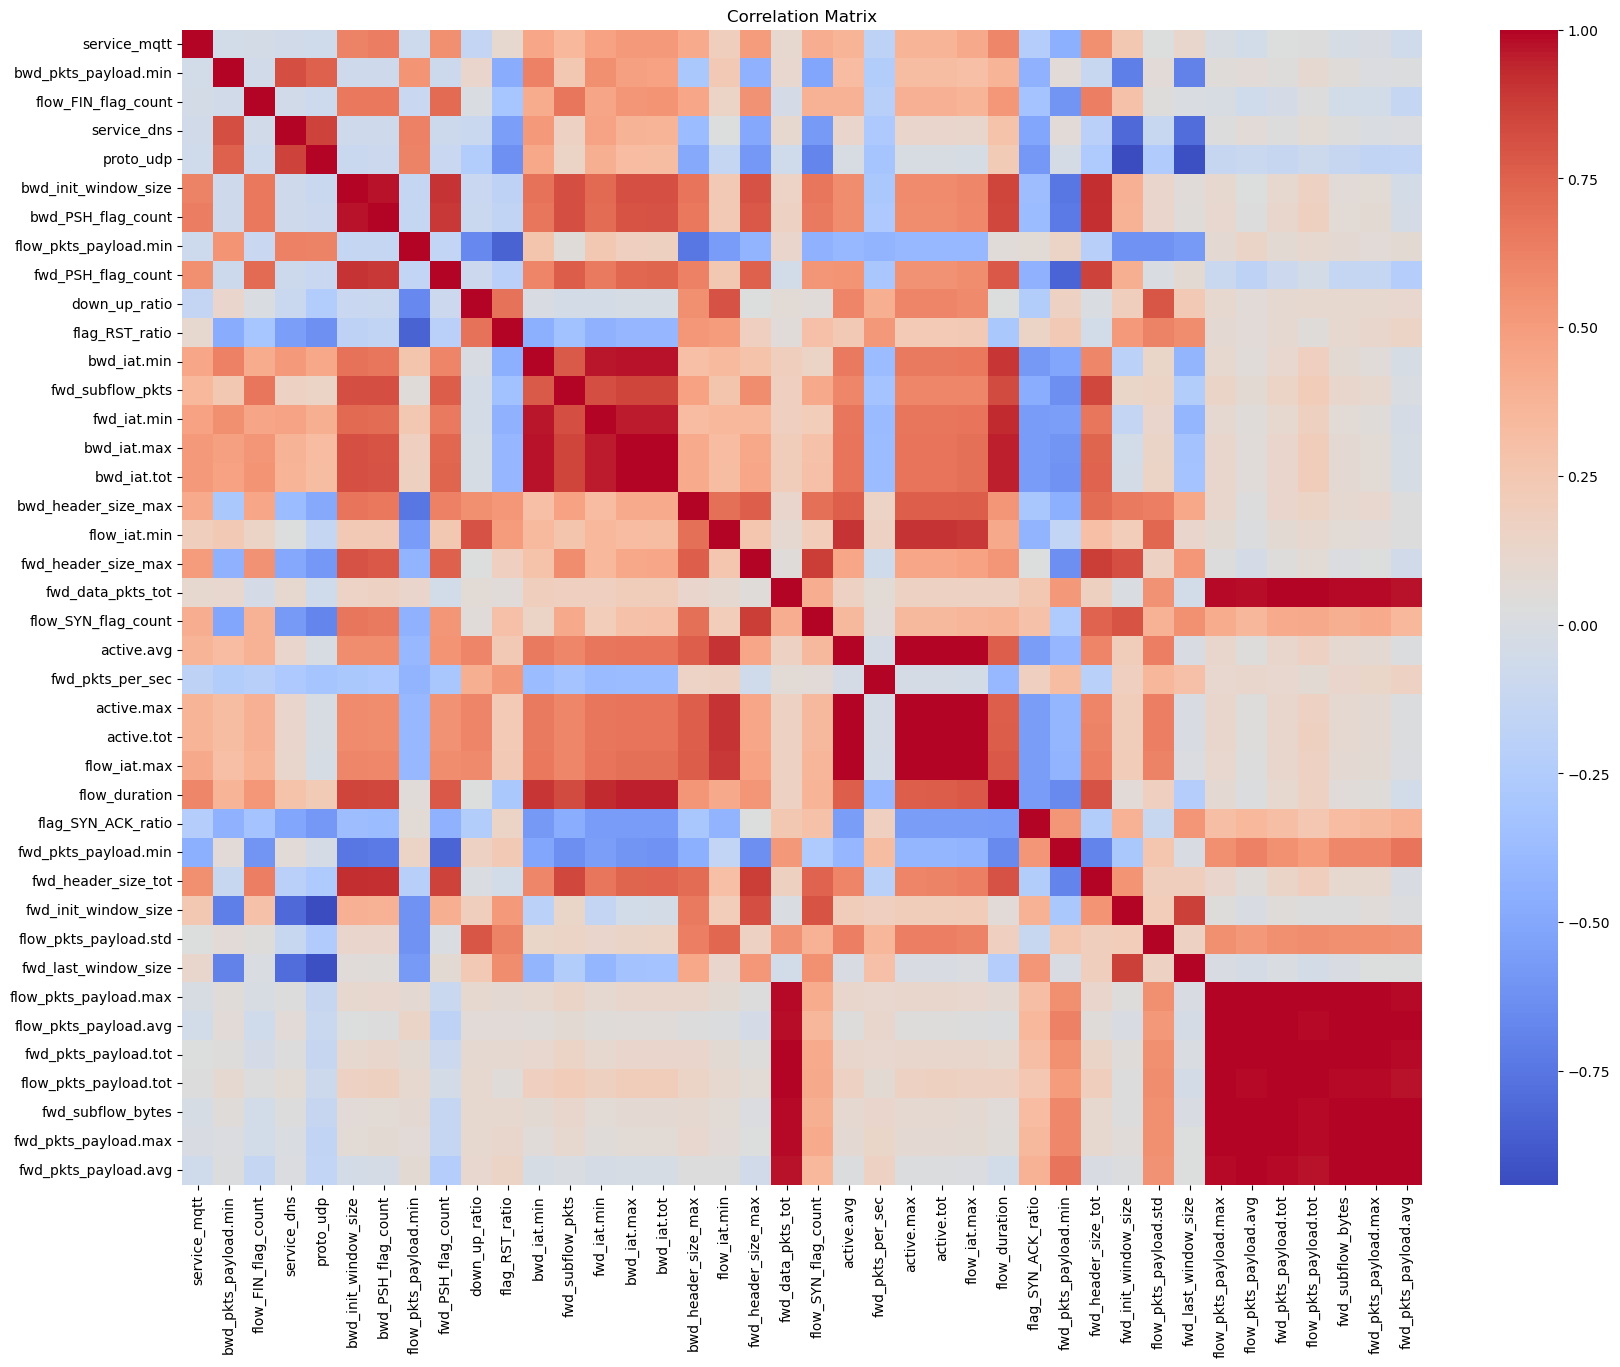

In [40]:
numeric_columns = X_scaled.select_dtypes(include=['number']).columns
correlation_matrix = X_scaled[numeric_columns].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [41]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)
print("Cumulative Variance:", explained_variance_ratio.cumsum())

pca_95 = PCA(n_components=0.95)
X_reduced = pca_95.fit_transform(X_scaled)
print("Before PCA: ", X_scaled.shape[1])
print("After PCA: ", X_reduced.shape[1])

pca_columns = [f'PC{i+1}' for i in range(X_reduced.shape[1])]
X_pca = pd.DataFrame(X_reduced, columns=pca_columns)
X_pca.head()

Explained Variance Ratio: [3.58652559e-01 2.32052723e-01 1.90284385e-01 1.17277610e-01
 3.02520347e-02 2.07412000e-02 1.55158031e-02 7.36517615e-03
 5.82390513e-03 4.24813511e-03 4.08025255e-03 2.48403297e-03
 2.22057535e-03 1.92780832e-03 1.52176730e-03 1.31770037e-03
 9.23062337e-04 7.54077986e-04 6.19546029e-04 4.43047078e-04
 3.26263473e-04 2.68753435e-04 2.35699347e-04 1.78012380e-04
 1.35338559e-04 1.07318662e-04 6.16339976e-05 5.23491998e-05
 3.90135704e-05 2.95537804e-05 2.74235209e-05 1.59787696e-05
 7.62794699e-06 3.86557160e-06 3.05924620e-06 1.27568719e-06
 5.69173668e-07 4.33181247e-07 3.82917079e-07 4.62446179e-08]
Cumulative Variance: [0.35865256 0.59070528 0.78098967 0.89826728 0.92851931 0.94926051
 0.96477631 0.97214149 0.9779654  0.98221353 0.98629378 0.98877782
 0.99099839 0.9929262  0.99444797 0.99576567 0.99668873 0.99744281
 0.99806235 0.9985054  0.99883166 0.99910042 0.99933612 0.99951413
 0.99964947 0.99975679 0.99981842 0.99987077 0.99990978 0.99993934
 0.9999

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,11.427875,-1.372737,-1.461233,-2.303587,4.506690,-0.728824,0.013369
1,11.343566,-1.369994,-1.473291,-2.380952,4.491054,-0.786755,0.003821
2,11.346039,-1.375505,-1.490973,-2.361098,4.488787,-0.781126,-0.007362
3,11.350044,-1.381305,-1.478690,-2.369997,4.493427,-0.778769,0.004493
4,11.365965,-1.367579,-1.476351,-2.352015,4.493826,-0.769832,0.000206


# Features Distribution

In [43]:
X.describe()

,service_mqtt,bwd_pkts_payload.min,flow_FIN_flag_count,service_dns,proto_udp,bwd_init_window_size,bwd_PSH_flag_count,flow_pkts_payload.min,fwd_PSH_flag_count,down_up_ratio,...,fwd_init_window_size,flow_pkts_payload.std,fwd_last_window_size,flow_pkts_payload.max,flow_pkts_payload.avg,fwd_pkts_payload.tot,flow_pkts_payload.tot,fwd_subflow_bytes,fwd_pkts_payload.max,fwd_pkts_payload.avg
count,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,...,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05
mean,-2.166063e-16,9.256680e-17,-8.516145e-17,3.961859e-16,-3.258351e-16,-4.184019e-16,2.369710e-16,-1.670831e-16,6.294542e-17,1.407015e-16,...,-2.369710e-16,2.962138e-17,-2.999164e-16,-3.850779e-16,2.073496e-16,-3.850779e-16,-5.331848e-16,-4.739420e-16,-6.516703e-16,-5.924275e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,-2.537720e+00,...,-2.800696e+00,-2.257633e+00,-2.737414e+00,-4.108683e+00,-4.110417e+00,-4.113568e+00,-4.079001e+00,-4.113100e+00,-4.114502e+00,-4.098390e+00
25%,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,4.294865e-01,...,1.795638e-01,3.879106e-01,2.970300e-01,2.379029e-01,2.385538e-01,2.370450e-01,1.994091e-01,2.512891e-01,2.606354e-01,2.965159e-01
50%,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,4.294865e-01,...,1.795638e-01,4.563212e-01,2.970300e-01,2.379029e-01,2.385538e-01,2.370450e-01,1.994091e-01,2.512891e-01,2.606354e-01,2.965159e-01
75%,-1.865882e-01,-2.533144e-01,-2.423888e-01,-2.937033e-01,-3.360168e-01,-3.022774e-01,-2.954431e-01,-4.493481e-01,-3.353134e-01,4.294865e-01,...,1.795638e-01,4.563212e-01,2.970300e-01,2.379029e-01,2.385538e-01,2.370450e-01,1.994091e-01,2.512891e-01,2.606354e-01,2.965159e-01
max,5.359397e+00,4.717111e+00,2.088252e+01,3.404796e+00,2.976041e+00,3.426737e+00,4.889997e+00,2.634373e+00,4.289712e+00,1.552633e+01,...,1.328840e+00,8.113894e-01,1.467201e+00,1.115070e+00,9.569410e-01,2.280283e+00,2.876173e+00,1.676011e+00,8.417575e-01,8.628982e-01


In [44]:
X_pca.describe()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
count,1.228160e+05,122816.000000,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05,1.228160e+05
mean,8.886413e-17,0.000000,-5.924275e-17,-6.294542e-17,8.145878e-17,7.405344e-18,1.360732e-16
std,3.787640e+00,3.046668,2.758883e+00,2.165905e+00,1.100041e+00,9.108539e-01,7.878053e-01
min,-1.578759e+01,-13.064663,-7.884470e+00,-5.616119e+00,-1.327525e+01,-3.511749e+00,-3.229290e+00
25%,-9.733046e-01,-0.228439,-8.674596e-01,6.884239e-01,-1.342441e-01,-7.072289e-01,-6.530679e-01
50%,-5.819860e-01,1.334643,-6.689585e-01,7.069553e-01,3.531752e-02,2.444939e-01,-1.183978e-01
75%,-5.189629e-01,1.400753,-6.469698e-01,7.844537e-01,4.993997e-02,3.141754e-01,6.641101e-01
max,1.596383e+01,1.809402,9.237474e+00,8.231293e+00,5.504083e+00,9.221995e+00,2.926481e+00


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train) 

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [46]:
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

#rus = RandomUnderSampler(random_state=42)
X_pca_rus, y_pca_rus = rus.fit_resample(X_pca_train, y_pca_train) 

#smote = SMOTE(random_state=42)
X_pca_smote, y_pca_smote = smote.fit_resample(X_pca_train, y_pca_train)

In [47]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [48]:
def pred(model, X_train, y_train, X_test, y_test, title):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    evaluate_model(title, y_test, preds)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Undersampling
Accuracy: 0.9505373717635565
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.45      0.57      1566
           1       0.56      0.98      0.72       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.00      0.33      0.00         3
           5       0.06      0.50      0.11         2
           6       1.00      1.00      1.00       379
           7       0.86      1.00      0.92       203
           8       0.98      0.95      0.96       496
           9       1.00      1.00      1.00       382
          10       0.87      0.80      0.84      1605
          11       0.24      0.82      0.37        40

    accuracy                           0.95     24564
   macro avg       0.69      0.82      0.71     24564
weighted avg       0.97      0.95      0.96     24564



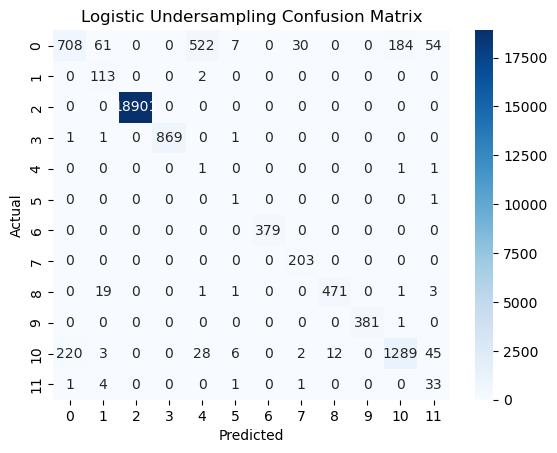

In [49]:
pred(LogisticRegression(), X_rus, y_rus, X_test, y_test, "Logistic Undersampling")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Oversampling
Accuracy: 0.9891711447646963
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1566
           1       0.78      0.99      0.87       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.01      0.33      0.02         3
           5       0.25      0.50      0.33         2
           6       1.00      1.00      1.00       379
           7       1.00      1.00      1.00       203
           8       0.98      0.95      0.96       496
           9       1.00      1.00      1.00       382
          10       0.97      0.94      0.96      1605
          11       0.47      1.00      0.63        40

    accuracy                           0.99     24564
   macro avg       0.78      0.88      0.81     24564
weighted avg       0.99      0.99      0.99     24564



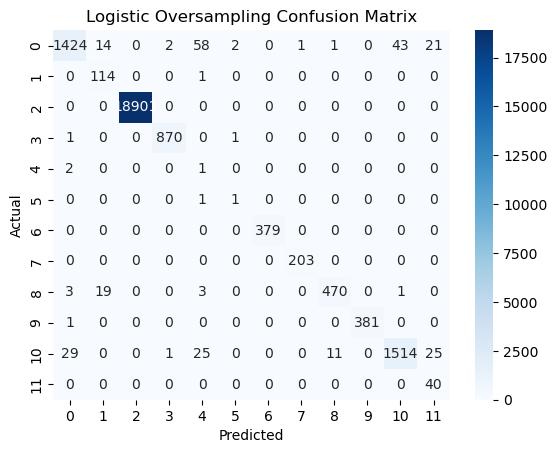

In [50]:
pred(LogisticRegression(), X_smote, y_smote, X_test, y_test, "Logistic Oversampling")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Undersampling (PCA)
Accuracy: 0.9125549584758182
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.22      0.32      1566
           1       0.14      0.95      0.24       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.02      0.67      0.04         3
           5       0.03      0.50      0.06         2
           6       0.99      1.00      0.99       379
           7       0.94      1.00      0.97       203
           8       0.48      0.95      0.64       496
           9       1.00      0.99      1.00       382
          10       0.59      0.46      0.52      1605
          11       0.18      0.45      0.26        40

    accuracy                           0.91     24564
   macro avg       0.58      0.77      0.59     24564
weighted avg       0.93      0.91      0.91     24564



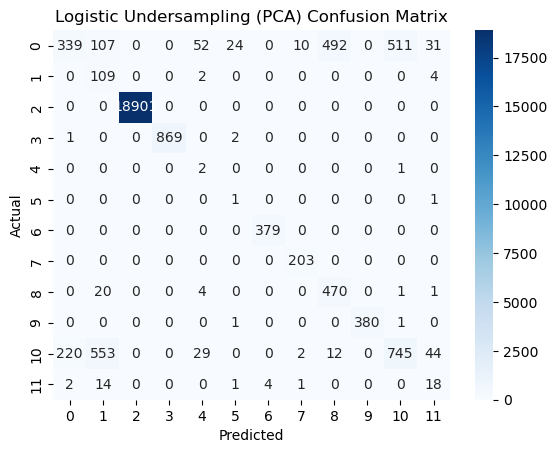

In [51]:
pred(LogisticRegression(), X_pca_rus, y_pca_rus, X_pca_test, y_pca_test, "Logistic Undersampling (PCA)")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Oversampling (PCA)
Accuracy: 0.9636459859957661
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.52      0.68      1566
           1       0.45      0.95      0.61       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.02      0.67      0.03         3
           5       0.05      0.50      0.09         2
           6       1.00      1.00      1.00       379
           7       1.00      1.00      1.00       203
           8       0.94      0.95      0.94       496
           9       0.99      0.99      0.99       382
          10       0.77      0.94      0.85      1605
          11       0.20      0.85      0.33        40

    accuracy                           0.96     24564
   macro avg       0.70      0.86      0.71     24564
weighted avg       0.98      0.96      0.97     24564



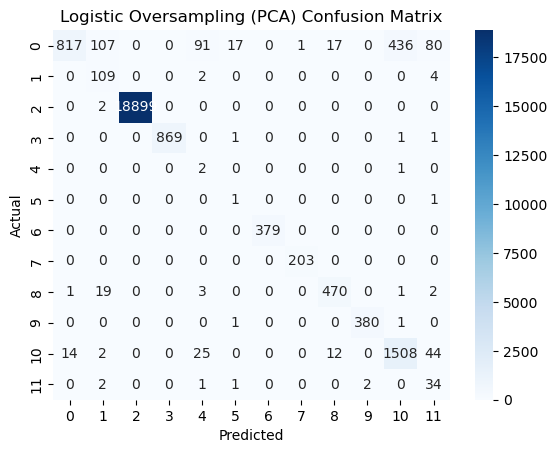

In [52]:
pred(LogisticRegression(), X_pca_smote, y_pca_smote, X_pca_test, y_pca_test, "Logistic Oversampling (PCA)")


RF Undersampling
Accuracy: 0.9688161537208924
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78      1566
           1       0.62      0.99      0.76       115
           2       1.00      1.00      1.00     18901
           3       0.99      1.00      1.00       872
           4       0.01      0.67      0.03         3
           5       0.11      0.50      0.18         2
           6       1.00      1.00      1.00       379
           7       0.86      1.00      0.93       203
           8       0.74      0.90      0.81       496
           9       1.00      1.00      1.00       382
          10       0.97      0.82      0.88      1605
          11       0.42      0.88      0.56        40

    accuracy                           0.97     24564
   macro avg       0.71      0.87      0.74     24564
weighted avg       0.98      0.97      0.97     24564



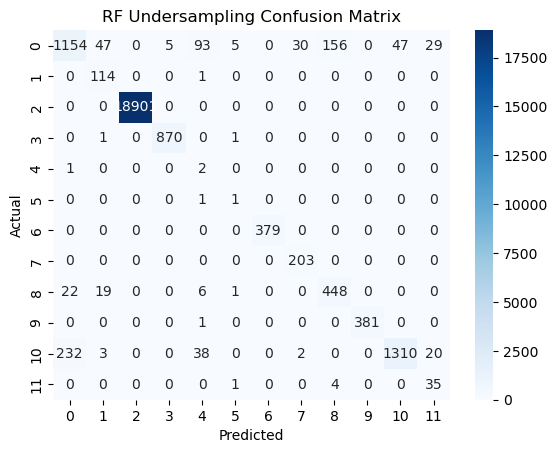

In [53]:
pred(RandomForestClassifier(random_state=42), X_rus, y_rus, X_test, y_test, "RF Undersampling")


RF Oversampling
Accuracy: 0.9978423709493568
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1566
           1       0.95      0.90      0.92       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       1.00      0.33      0.50         3
           5       1.00      0.50      0.67         2
           6       1.00      1.00      1.00       379
           7       1.00      1.00      1.00       203
           8       0.97      0.98      0.98       496
           9       1.00      1.00      1.00       382
          10       0.99      0.99      0.99      1605
          11       1.00      1.00      1.00        40

    accuracy                           1.00     24564
   macro avg       0.99      0.89      0.92     24564
weighted avg       1.00      1.00      1.00     24564



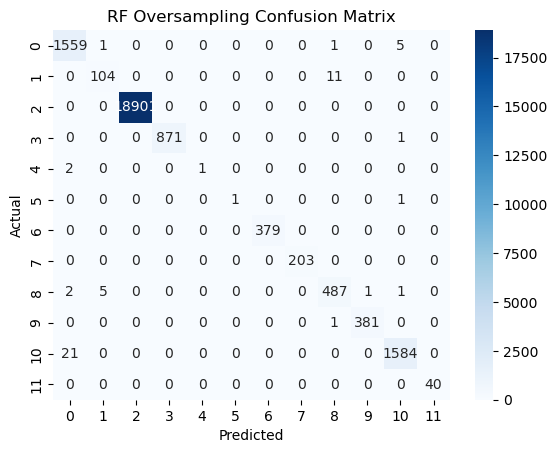

In [54]:
pred(RandomForestClassifier(random_state=42), X_smote, y_smote, X_test, y_test, "RF Oversampling")


RF Undersampling (PCA)
Accuracy: 0.9583943983064648
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67      1566
           1       0.70      0.97      0.81       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.00      0.33      0.01         3
           5       0.04      0.50      0.07         2
           6       1.00      1.00      1.00       379
           7       0.87      1.00      0.93       203
           8       0.97      0.95      0.96       496
           9       0.99      1.00      0.99       382
          10       0.86      0.80      0.83      1605
          11       0.35      0.82      0.49        40

    accuracy                           0.96     24564
   macro avg       0.71      0.83      0.73     24564
weighted avg       0.97      0.96      0.96     24564



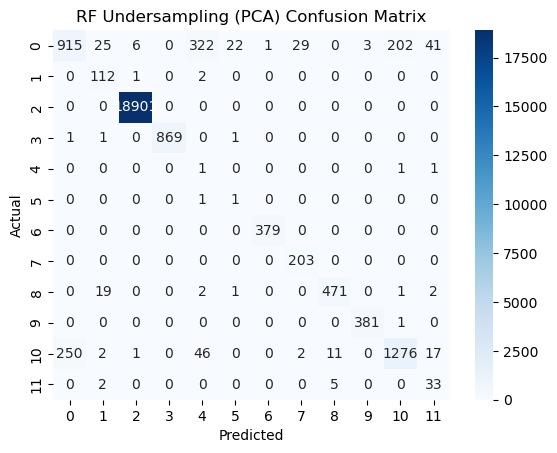

In [55]:
pred(RandomForestClassifier(random_state=42), X_pca_rus, y_pca_rus, X_pca_test, y_pca_test, "RF Undersampling (PCA)")


RF Oversampling (PCA)
Accuracy: 0.9967024914509037
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1566
           1       0.95      0.90      0.92       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.33      0.33      0.33         3
           5       0.33      0.50      0.40         2
           6       1.00      1.00      1.00       379
           7       1.00      1.00      1.00       203
           8       0.98      0.98      0.98       496
           9       1.00      1.00      1.00       382
          10       0.99      0.98      0.98      1605
          11       0.93      1.00      0.96        40

    accuracy                           1.00     24564
   macro avg       0.87      0.89      0.88     24564
weighted avg       1.00      1.00      1.00     24564



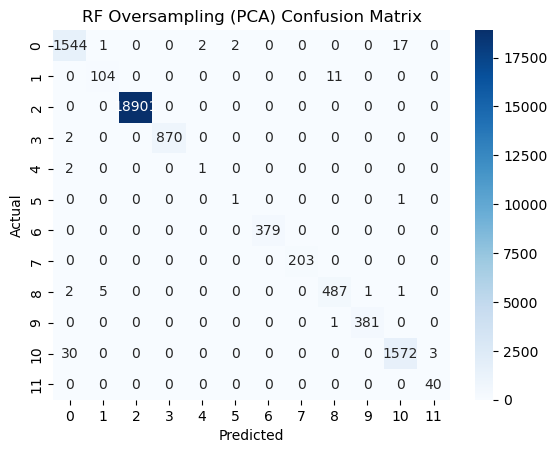

In [56]:
pred(RandomForestClassifier(random_state=42), X_pca_smote, y_pca_smote, X_pca_test, y_pca_test, "RF Oversampling (PCA)")


KNN Undersampling
Accuracy: 0.9133284481354829
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.24      0.34      1566
           1       0.72      0.96      0.82       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.00      0.67      0.01         3
           5       0.06      0.50      0.11         2
           6       1.00      1.00      1.00       379
           7       0.90      1.00      0.95       203
           8       0.99      0.91      0.95       496
           9       1.00      0.99      1.00       382
          10       0.62      0.47      0.53      1605
          11       0.03      0.55      0.06        40

    accuracy                           0.91     24564
   macro avg       0.66      0.77      0.65     24564
weighted avg       0.95      0.91      0.92     24564



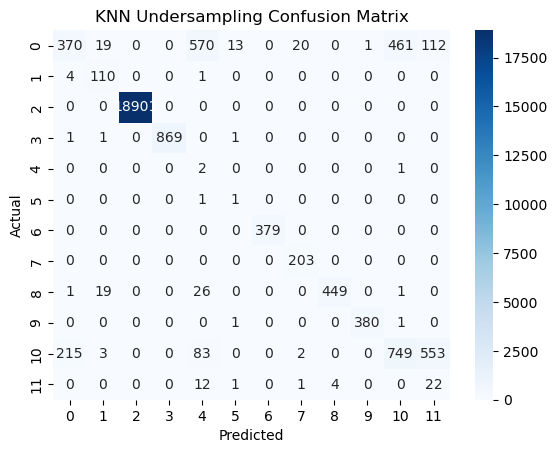

In [57]:
pred(KNeighborsClassifier(), X_rus, y_rus, X_test, y_test, "KNN Undersampling")


KNN Oversampling
Accuracy: 0.9968653313792541
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1566
           1       0.94      0.90      0.92       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.33      0.33      0.33         3
           5       0.50      0.50      0.50         2
           6       1.00      1.00      1.00       379
           7       1.00      1.00      1.00       203
           8       0.97      0.98      0.98       496
           9       1.00      1.00      1.00       382
          10       0.99      0.98      0.98      1605
          11       0.89      1.00      0.94        40

    accuracy                           1.00     24564
   macro avg       0.88      0.89      0.89     24564
weighted avg       1.00      1.00      1.00     24564



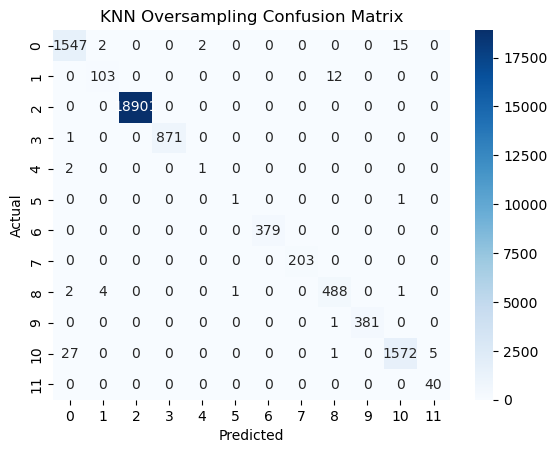

In [58]:
pred(KNeighborsClassifier(), X_smote, y_smote, X_test, y_test, "KNN Oversampling")


KNN Undersampling (PCA)
Accuracy: 0.8271861260381046
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.11      0.17      1566
           1       0.71      0.96      0.81       115
           2       1.00      0.90      0.95     18901
           3       1.00      1.00      1.00       872
           4       0.00      0.67      0.00         3
           5       0.06      0.50      0.11         2
           6       1.00      1.00      1.00       379
           7       0.91      1.00      0.96       203
           8       0.99      0.95      0.97       496
           9       0.99      0.99      0.99       382
          10       0.58      0.47      0.52      1605
          11       0.03      0.50      0.05        40

    accuracy                           0.83     24564
   macro avg       0.64      0.75      0.63     24564
weighted avg       0.93      0.83      0.87     24564



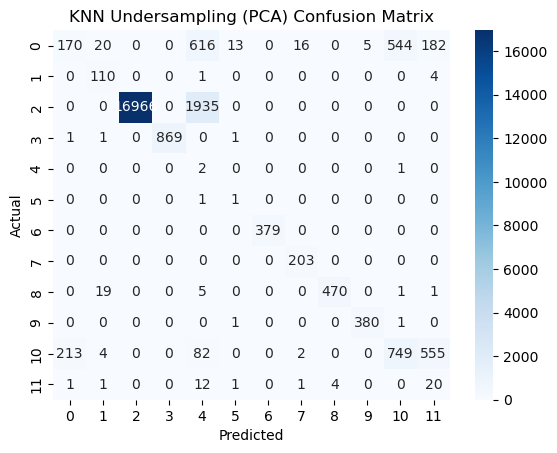

In [59]:
pred(KNeighborsClassifier(), X_pca_rus, y_pca_rus, X_pca_test, y_pca_test, "KNN Undersampling (PCA)")


KNN Oversampling (PCA)
Accuracy: 0.9959290017912392
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1566
           1       0.93      0.88      0.90       115
           2       1.00      1.00      1.00     18901
           3       1.00      1.00      1.00       872
           4       0.33      0.33      0.33         3
           5       0.20      0.50      0.29         2
           6       1.00      1.00      1.00       379
           7       1.00      1.00      1.00       203
           8       0.97      0.98      0.97       496
           9       1.00      1.00      1.00       382
          10       0.98      0.98      0.98      1605
          11       0.89      1.00      0.94        40

    accuracy                           1.00     24564
   macro avg       0.86      0.89      0.87     24564
weighted avg       1.00      1.00      1.00     24564



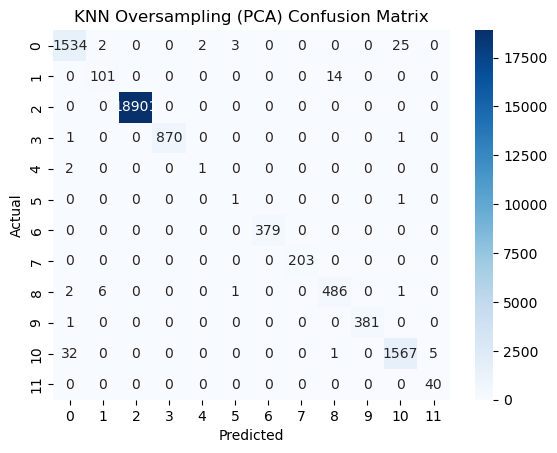

In [60]:
pred(KNeighborsClassifier(), X_pca_smote, y_pca_smote, X_pca_test, y_pca_test, "KNN Oversampling (PCA)")

In [61]:
def sampling_PCA_heatmap(data, title):
    index = ['RUS', 'Smote', 'RUS (PCA)', 'Smote (PCA)']
    df = pd.DataFrame(data, index=index)
    plt.figure(figsize=(8, 5))
    sns.heatmap(df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Model Performance Heatmap: ' + title)
    plt.show()

In [62]:
accuracy = {
    'LR': [0.95, 0.99, 0.91, 0.96],
    'RF': [0.97, 1.00, 0.96, 1.00],
    'KNN': [0.91, 1.00, 0.83, 1.00]
}

precision = {
    'LR': [0.97, 0.99, 0.93, 0.98],
    'RF': [0.98, 1.00, 0.97, 1.00],
    'KNN': [0.95, 1.00, 0.93, 1.00]
}

recall = {
    'LR': [0.95, 0.99, 0.91, 0.96],
    'RF': [0.97, 1.00, 0.96, 1.00],
    'KNN': [0.91, 1.00, 0.83, 1.00]
}

f1score = {
    'LR': [0.96, 0.99, 0.91, 0.97],
    'RF': [0.97, 1.00, 0.96, 1.00],
    'KNN': [0.92, 1.00, 0.87, 1.00]
}

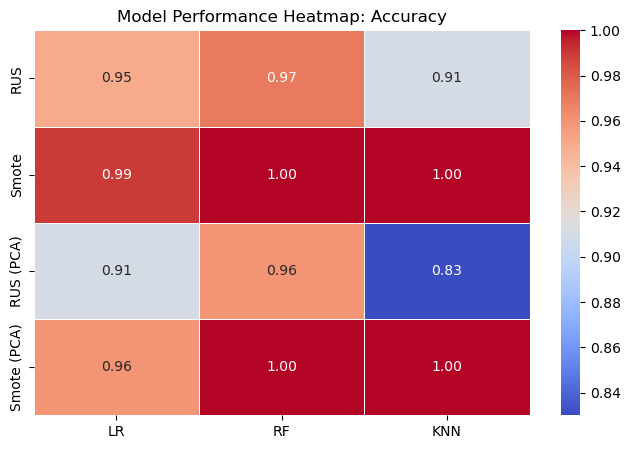

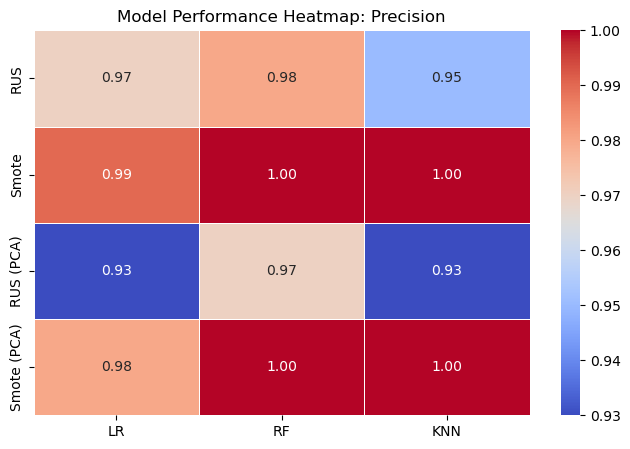

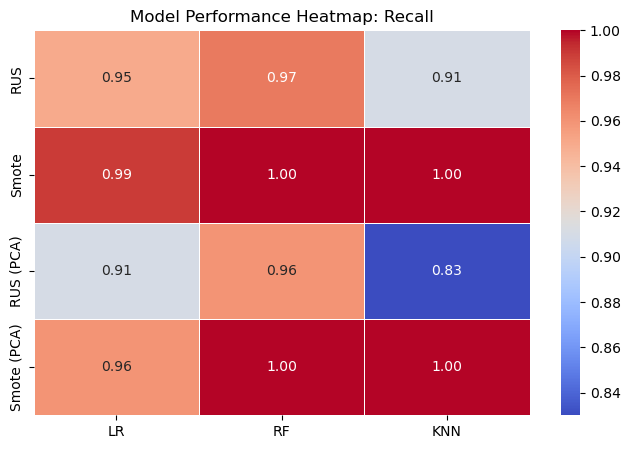

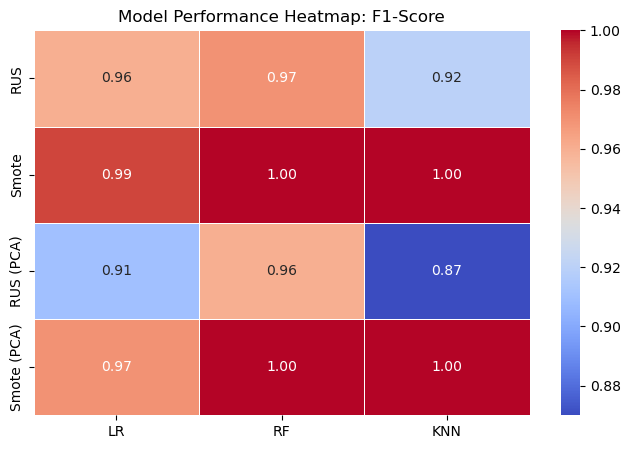

In [63]:
sampling_PCA_heatmap(accuracy, 'Accuracy')
sampling_PCA_heatmap(precision, 'Precision')
sampling_PCA_heatmap(recall, 'Recall')
sampling_PCA_heatmap(f1score, 'F1-Score')

# Tuning & Results

In [65]:
def showResult(final_model, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        final_model, X_trainval, y_trainval, cv=inner_cv, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, shuffle=True, random_state=42
    )

    train_scores_mean = train_scores.mean(axis=1)
    valid_scores_mean = valid_scores.mean(axis=1)

    y_test_pred = final_model.predict(X_test)

    cm = confusion_matrix(y_test, y_test_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_sizes, train_scores_mean, label='Training accuracy')
    axes[0].plot(train_sizes, valid_scores_mean, label='Validation accuracy')
    axes[0].set_xlabel('Training set size')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'{title} - Learning Curve')
    axes[0].legend()
    axes[0].grid(True)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
    axes[1].set_title(f'{title} - Confusion Matrix')

    plt.tight_layout()
    plt.show()

    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, average='weighted')
    rec = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    print(f"[{title}] Test Accuracy: {acc:.4f}")
    print(f"[{title}] Test Precision: {prec:.4f}")
    print(f"[{title}] Test Recall: {rec:.4f}")
    print(f"[{title}] Test F1-score: {f1:.4f}")


Fold 1 - Outer validation accuracy: 0.7059
Fold 1 - Best params: {'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       0.50      0.50      0.50         2
          11       0.00      0.00      0.00         1

    accuracy                           0.71        17
   macro avg       0.65      0.71      0.67        17
weighted avg       0.67      0.71      0.68        17



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 2 - Outer validation accuracy: 0.7059
Fold 2 - Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1
           3       1.00      1.00      1.00         2
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         1
          10       1.00      0.50      0.67         2
          11       0.33      1.00      0.50         1

    accuracy                           0.71        17
   macro avg       0.65      0.71      0.65        17
weighted avg       0.70      0.71      0.68        17



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 3 - Outer validation accuracy: 0.7647
Fold 3 - Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           4       0.33      1.00      0.50         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         1
          10       0.00      0.00      0.00         1
          11       1.00      0.50      0.67         2

    accuracy                           0.76        17
   macro avg       0.78      0.75      0.74        17
weighted avg       0.84      0.76      0.77        17



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 4 - Outer validation accuracy: 0.8235
Fold 4 - Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         2
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         2
          10       0.50      1.00      0.67         1
          11       1.00      1.00      1.00         2

    accuracy                           0.82        17
   macro avg       0.76      0.83      0.79        17
weighted avg       0.75      0.82      0.78        17



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5 - Outer validation accuracy: 0.6875
Fold 5 - Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         2
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       0.33      1.00      0.50         1
           9       1.00      1.00      1.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1

    accuracy                           0.69        16
   macro avg       0.57      0.67      0.60        16
weighted avg       0.61      0.69      0.64        16

Mean ou

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


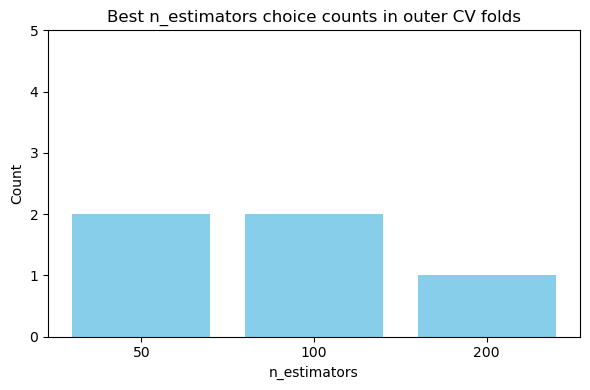

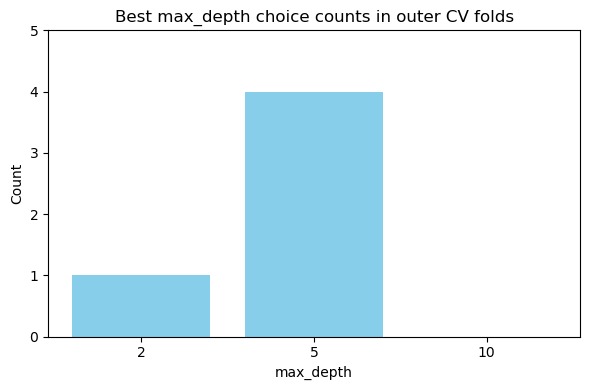

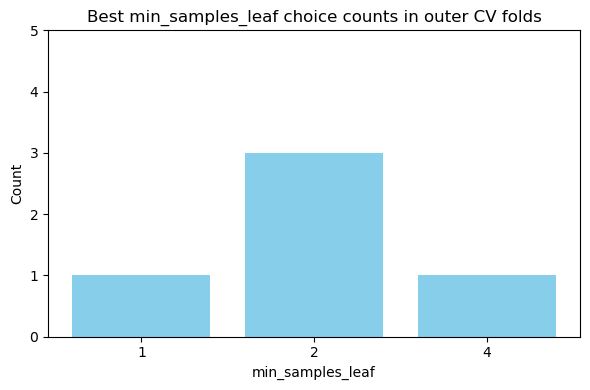

In [66]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pca.values, y, test_size=0.2, random_state=42, stratify=y)

rus = RandomUnderSampler(random_state=42)
X_trainval, y_trainval = rus.fit_resample(X_trainval, y_trainval)
#smote = SMOTE(random_state=42)
#X_trainval, y_trainval = smote.fit_resample(X_trainval, y_trainval)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_params_list = []
outer_scores = []

for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_trainval, y_trainval), 1):
    X_train, X_valid = X_trainval[train_idx], X_trainval[valid_idx]
    y_train, y_valid = y_trainval[train_idx], y_trainval[valid_idx]

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_params_list.append(grid_search.best_params_)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_valid)

    score = accuracy_score(y_valid, y_pred)
    outer_scores.append(score)

    print(f"Fold {fold} - Outer validation accuracy: {score:.4f}")
    print(f"Fold {fold} - Best params: {grid_search.best_params_}")
    print(classification_report(y_valid, y_pred))

print(f"Mean outer CV accuracy: {np.mean(outer_scores):.4f}")

def count_best_param_choices(best_params_list, param_grid):
    counts = {param: {val: 0 for val in vals} for param, vals in param_grid.items()}
    for best_params in best_params_list:
        for param, val in best_params.items():
            counts[param][val] += 1
    return counts

counts = count_best_param_choices(best_params_list, param_grid)

for param, val_counts in counts.items():
    plt.figure(figsize=(6,4))
    vals = list(val_counts.keys())
    counts_list = list(val_counts.values())
    vals_str = [str(v) if v is not None else 'None' for v in vals]
    
    plt.bar(vals_str, counts_list, color='skyblue')
    plt.title(f"Best {param} choice counts in outer CV folds")
    plt.xlabel(param)
    plt.ylabel("Count")
    plt.ylim(0, len(best_params_list))  
    plt.tight_layout()
    plt.show()


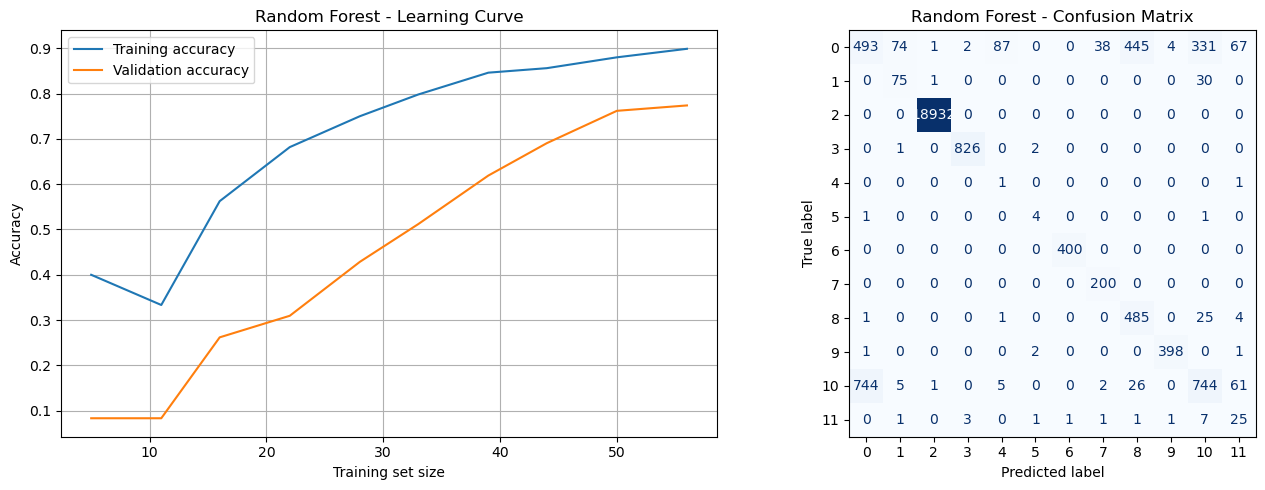

[Random Forest] Test Accuracy: 0.9194
[Random Forest] Test Precision: 0.9236
[Random Forest] Test Recall: 0.9194
[Random Forest] Test F1-score: 0.9185


In [67]:
showResult(best_model, "Random Forest")

Fold 1 - Outer validation accuracy: 0.6471
Fold 1 - Best params: {'C': 0.1, 'max_iter': 1000}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.20      1.00      0.33         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         1

    accuracy                           0.65        17
   macro avg       0.60      0.67      0.61        17
weighted avg       0.60      0.65      0.61        17

Fold 2 - Outer validation accuracy: 0.7

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-pa

Fold 5 - Outer validation accuracy: 0.6875
Fold 5 - Best params: {'C': 0.1, 'max_iter': 1000}
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         2
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       0.50      1.00      0.67         1
           9       1.00      1.00      1.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1

    accuracy                           0.69        16
   macro avg       0.58      0.67      0.61        16
weighted avg       0.62      0.69      0.65        16


Mean outer CV accuracy: 0.6904


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


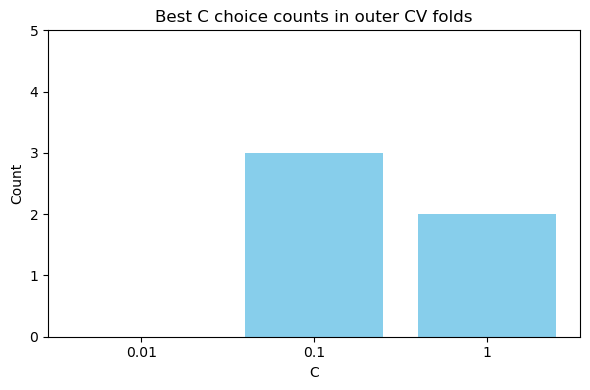

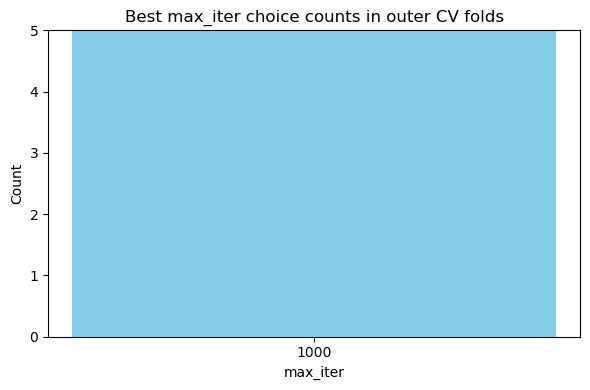

In [68]:
logreg = LogisticRegression(random_state=42)

param_grid = {
    'C': [0.01, 0.1, 1],     
    'max_iter': [1000]
}

best_params_list = []
outer_scores = []

for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_trainval, y_trainval), 1):
    X_train, X_valid = X_trainval[train_idx], X_trainval[valid_idx]
    y_train, y_valid = y_trainval[train_idx], y_trainval[valid_idx]

    grid_search = GridSearchCV(
        estimator=logreg,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_params_list.append(grid_search.best_params_)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_valid)

    score = accuracy_score(y_valid, y_pred)
    outer_scores.append(score)

    print(f"Fold {fold} - Outer validation accuracy: {score:.4f}")
    print(f"Fold {fold} - Best params: {grid_search.best_params_}")
    print(classification_report(y_valid, y_pred))

print(f"\nMean outer CV accuracy: {np.mean(outer_scores):.4f}")

def count_best_param_choices(best_params_list, param_grid):
    counts = {param: {val: 0 for val in vals} for param, vals in param_grid.items()}
    for best_params in best_params_list:
        for param, val in best_params.items():
            counts[param][val] += 1
    return counts

counts = count_best_param_choices(best_params_list, param_grid)

for param, val_counts in counts.items():
    plt.figure(figsize=(6,4))
    vals = list(val_counts.keys())
    counts_list = list(val_counts.values())
    vals_str = [str(v) if v is not None else 'None' for v in vals]
    
    plt.bar(vals_str, counts_list, color='skyblue')
    plt.title(f"Best {param} choice counts in outer CV folds")
    plt.xlabel(param)
    plt.ylabel("Count")
    plt.ylim(0, len(best_params_list))  
    plt.tight_layout()
    plt.show()


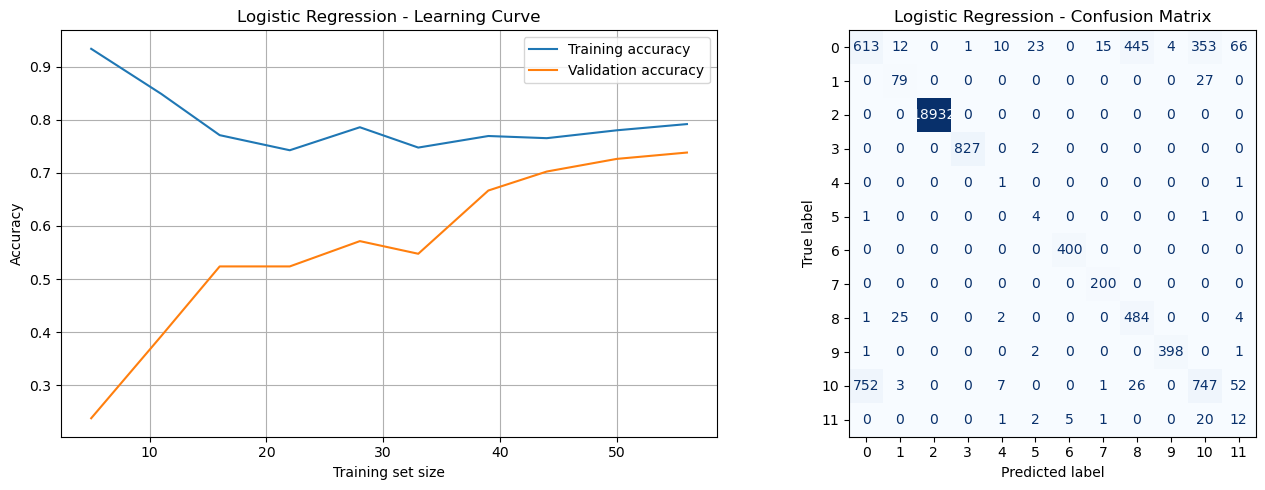

[Logistic Regression] Test Accuracy: 0.9240
[Logistic Regression] Test Precision: 0.9281
[Logistic Regression] Test Recall: 0.9240
[Logistic Regression] Test F1-score: 0.9235


In [69]:
showResult(best_model, "Logistic Regression")

Fold 1 - Outer validation accuracy: 0.7647
Fold 1 - Best params: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       0.50      1.00      0.67         2
          11       0.00      0.00      0.00         1

    accuracy                           0.76        17
   macro avg       0.71      0.75      0.72        17
weighted avg       0.71      0.76      0.73        17

Fold 2 - Outer val

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-pa

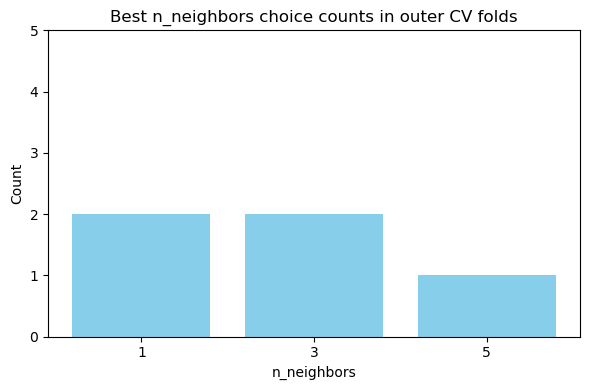

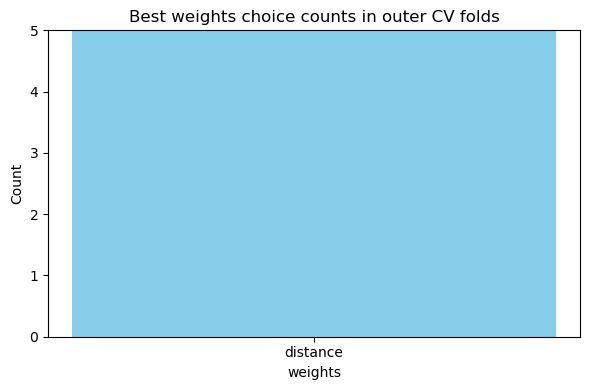

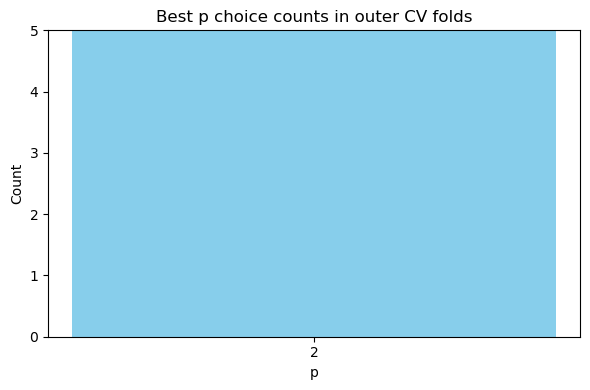

In [70]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [1, 3, 5],
    'weights': ['distance'], 
    'p': [2]  
}

best_params_list = []
outer_scores = []

for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_trainval, y_trainval), 1):
    X_train, X_valid = X_trainval[train_idx], X_trainval[valid_idx]
    y_train, y_valid = y_trainval[train_idx], y_trainval[valid_idx]

    grid_search = GridSearchCV(
        estimator=knn,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_params_list.append(grid_search.best_params_)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_valid)

    score = accuracy_score(y_valid, y_pred)
    outer_scores.append(score)

    print(f"Fold {fold} - Outer validation accuracy: {score:.4f}")
    print(f"Fold {fold} - Best params: {grid_search.best_params_}")
    print(classification_report(y_valid, y_pred))

print(f"\nMean outer CV accuracy: {np.mean(outer_scores):.4f}")


def count_best_param_choices(best_params_list, param_grid):
    counts = {param: {val: 0 for val in vals} for param, vals in param_grid.items()}
    for best_params in best_params_list:
        for param, val in best_params.items():
            counts[param][val] += 1
    return counts

counts = count_best_param_choices(best_params_list, param_grid)


for param, val_counts in counts.items():
    plt.figure(figsize=(6,4))
    vals = list(val_counts.keys())
    counts_list = list(val_counts.values())
    vals_str = [str(v) if v is not None else 'None' for v in vals]
    
    plt.bar(vals_str, counts_list, color='skyblue')
    plt.title(f"Best {param} choice counts in outer CV folds")
    plt.xlabel(param)
    plt.ylabel("Count")
    plt.ylim(0, len(best_params_list))  
    plt.tight_layout()
    plt.show()


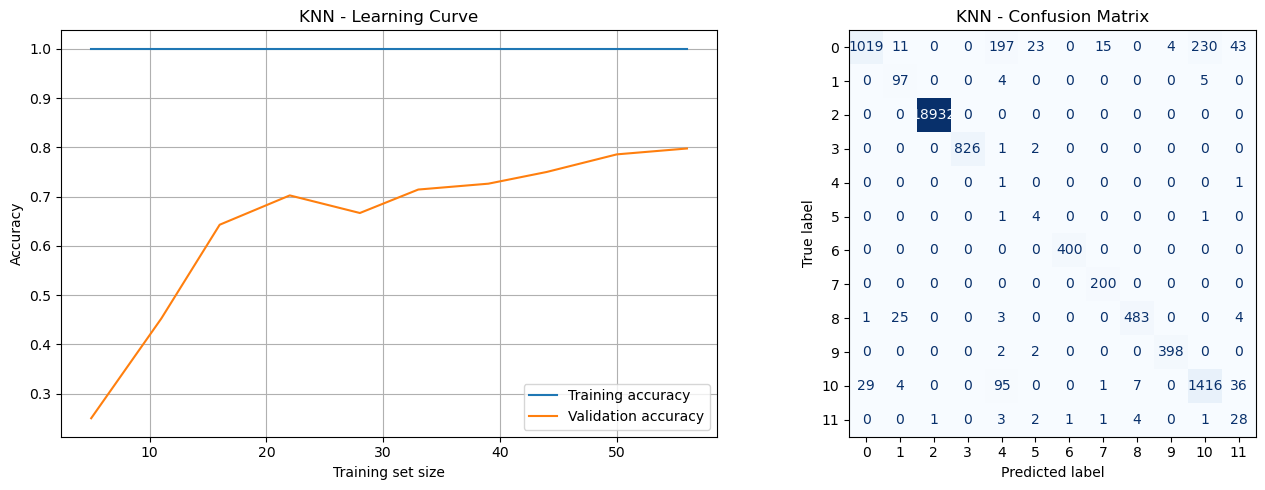

[KNN] Test Accuracy: 0.9691
[KNN] Test Precision: 0.9848
[KNN] Test Recall: 0.9691
[KNN] Test F1-score: 0.9747


In [71]:
showResult(best_model, "KNN")

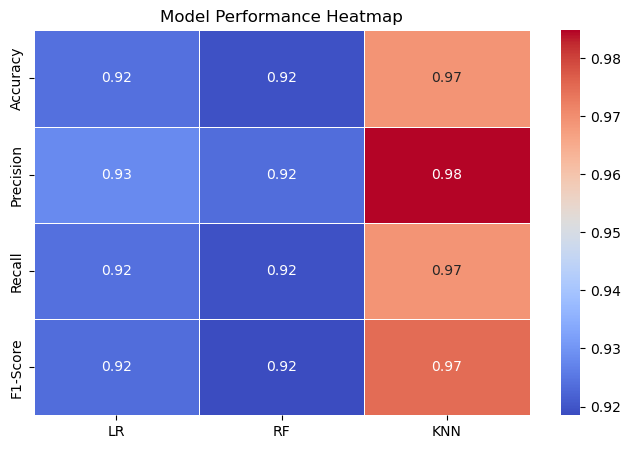

In [72]:
index = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics = {
    'LR': [0.9240, 0.9281, 0.9240, 0.9235],
    'RF': [0.9194, 0.9236, 0.9194, 0.9185],
    'KNN': [0.9691, 0.9848, 0.9691, 0.9747]
}

metric_df = pd.DataFrame(metrics, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(metric_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Model Performance Heatmap')
plt.show()